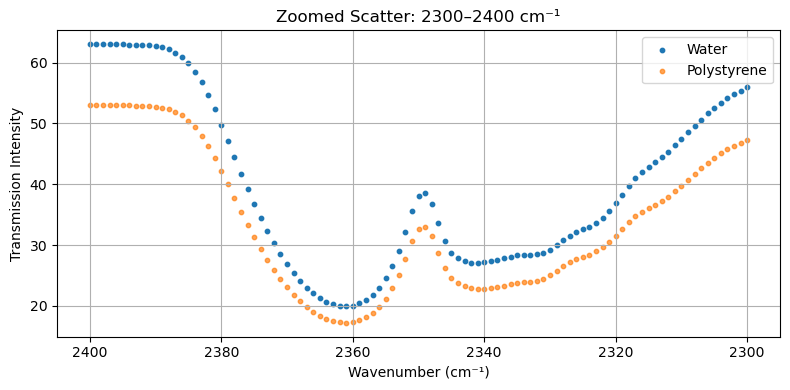

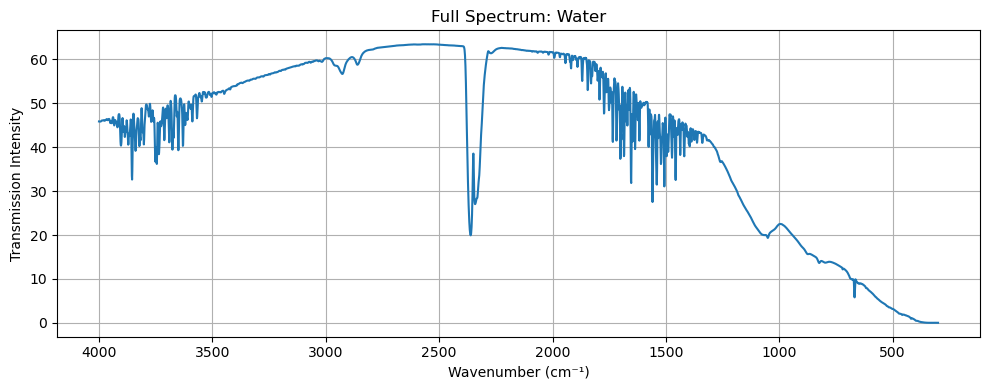

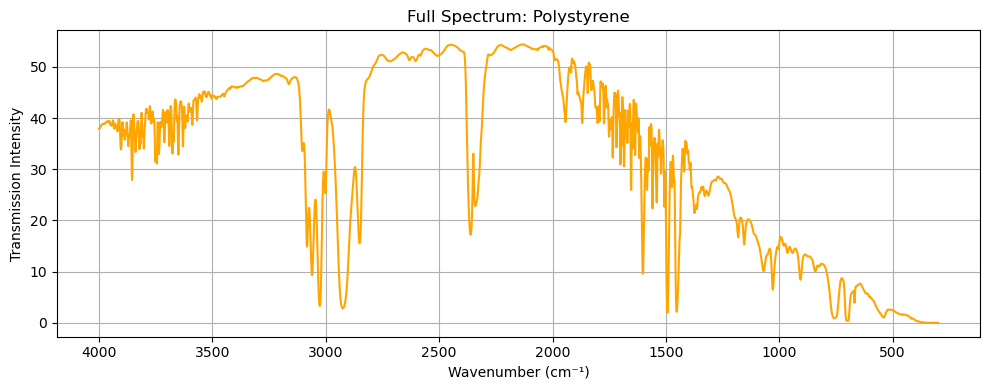

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Load ASC file with robust parsing ---
def read_spectrum(filepath):
    with open(filepath, encoding='utf-8') as f:
        lines = f.readlines()[25:]  # Skip header lines

    data = []
    for line in lines:
        matches = re.findall(r"\d+,\d+", line)
        if len(matches) >= 2:
            try:
                wn = float(matches[0].replace(",", "."))
                intensity = float(matches[1].replace(",", "."))
                data.append((wn, intensity))
            except ValueError:
                continue
    return pd.DataFrame(data, columns=["Wavenumber", "Intensity"])

# --- Load files ---
df_water = read_spectrum("h2o.ASC")
df_polystyrene = read_spectrum("polystyrene.ASC")

# --- Plot 1: Scatter zoomed into 2300–2400 cm⁻¹ range ---
df_water_zoom = df_water[(df_water["Wavenumber"] >= 2300) & (df_water["Wavenumber"] <= 2400)]
df_polystyrene_zoom = df_polystyrene[(df_polystyrene["Wavenumber"] >= 2300) & (df_polystyrene["Wavenumber"] <= 2400)]

plt.figure(figsize=(8, 4))
plt.scatter(df_water_zoom["Wavenumber"], df_water_zoom["Intensity"], label="Water", s=10)
plt.scatter(df_polystyrene_zoom["Wavenumber"], df_polystyrene_zoom["Intensity"], label="Polystyrene", s=10, alpha=0.7)
plt.gca().invert_xaxis()
plt.title("Zoomed Scatter: 2300–2400 cm⁻¹")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Transmission Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Full Water spectrum ---
plt.figure(figsize=(10, 4))
plt.plot(df_water["Wavenumber"], df_water["Intensity"], label="Water")
plt.gca().invert_xaxis()
plt.title("Full Spectrum: Water")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Transmission Intensity")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 3: Full Polystyrene spectrum ---
plt.figure(figsize=(10, 4))
plt.plot(df_polystyrene["Wavenumber"], df_polystyrene["Intensity"], label="Polystyrene", color="orange")
plt.gca().invert_xaxis()
plt.title("Full Spectrum: Polystyrene")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Transmission Intensity")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import re
import numpy as np

# --- STEP 1: Read ASC spectrum files ---
def read_spectrum(filepath):
    with open(filepath, encoding='utf-8') as f:
        lines = f.readlines()[25:]
    data = []
    for line in lines:
        matches = re.findall(r"\d+,\d+", line)
        if len(matches) >= 2:
            try:
                wn = float(matches[0].replace(",", "."))
                intensity = float(matches[1].replace(",", "."))
                data.append((wn, intensity))
            except ValueError:
                continue
    return pd.DataFrame(data, columns=["Wavenumber", "Intensity"])

df_water = read_spectrum("h2o.ASC")
df_polystyrene = read_spectrum("polystyrene.ASC")

# --- STEP 2: Detect valleys (absorption peaks) ---
def detect_peaks(df, prominence=0.0001):
    peaks, _ = find_peaks(-df["Intensity"], prominence=prominence)
    return df.iloc[peaks][["Wavenumber", "Intensity"]].reset_index(drop=True)

peaks_water = detect_peaks(df_water)
peaks_poly = detect_peaks(df_polystyrene)

# --- STEP 3: Theoretical reference values (from image) ---
ref_water = [1942.6, 1869.3, 1844.2, 1791.8, 1734.0, 1652.8, 1616.7, 1576.2, 1521.4, 1456.8,
             1436.7, 1419.3, 1387.5, 502.3, 472.3, 457.8, 400.4, 302.4, 278.3, 266.2, 253.9]

ref_polystyrene = [3081.5, 3059.5, 3025.6, 2922.3, 2850.3, 1942.6, 1802.4, 1601.4, 1583.1, 1492.8,
                   1452.3, 1181.5, 1154.5, 1069.0, 1028.5, 906.9, 699.8, 541.0]

# --- STEP 4: Match nearest detected peak to each expected value ---
def match_peaks(peaks_df, reference_peaks):
    matched = []
    peaks_df["Wavenumber"] = pd.to_numeric(peaks_df["Wavenumber"], errors="coerce")
    peaks_df.dropna(subset=["Wavenumber"], inplace=True)

    for ref in reference_peaks:
        try:
            closest_idx = (peaks_df["Wavenumber"] - ref).abs().idxmin()
            found = peaks_df.loc[closest_idx, "Wavenumber"]
            deviation = found - ref
            matched.append((ref, found, deviation))
        except:
            matched.append((ref, None, None))  # fallback in case matching fails
    return pd.DataFrame(matched, columns=["Expected", "Found", "Deviation"])

matched_water = match_peaks(peaks_water, ref_water)
matched_poly = match_peaks(peaks_poly, ref_polystyrene)

# --- STEP 5: Combine into one LaTeX-style table ---
table_df = pd.DataFrame({
    "Water Expected": matched_water["Expected"],
    "Water Found": matched_water["Found"],
    "Water Deviation": matched_water["Deviation"],
    "Polystyrene Expected": matched_poly["Expected"],
    "Polystyrene Found": matched_poly["Found"],
    "Polystyrene Deviation": matched_poly["Deviation"]
})

# --- STEP 6: Compute MAE ---
mae_water = matched_water["Deviation"].abs().mean()
mae_poly = matched_poly["Deviation"].abs().mean()

# --- Print result ---
print(table_df.to_string(index=False, float_format="%.2f"))
print(f"\nMean Absolute Error (Water): {mae_water:.2f} cm⁻¹")
print(f"Mean Absolute Error (Polystyrene): {mae_poly:.2f} cm⁻¹")


 Water Expected  Water Found  Water Deviation  Polystyrene Expected  Polystyrene Found  Polystyrene Deviation
        1942.60      1943.00             0.40               3081.50            3083.00                   1.50
        1869.30      1869.00            -0.30               3059.50            3060.00                   0.50
        1844.20      1845.00             0.80               3025.60            3026.00                   0.40
        1791.80      1793.00             1.20               2922.30            2925.00                   2.70
        1734.00      1734.00             0.00               2850.30            2850.00                  -0.30
        1652.80      1653.00             0.20               1942.60            1943.00                   0.40
        1616.70      1617.00             0.30               1802.40            1801.00                  -1.40
        1576.20      1576.00            -0.20               1601.40            1602.00                   0.60
        15

# Task 2 -----------------------------------------------------------------------------------------------

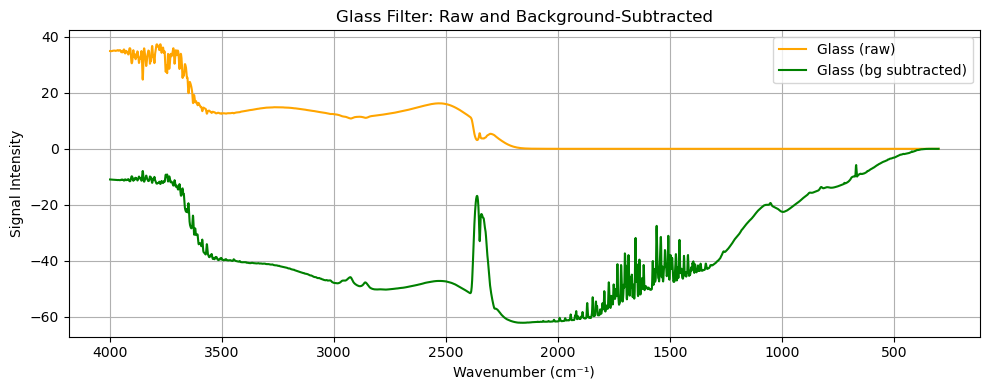

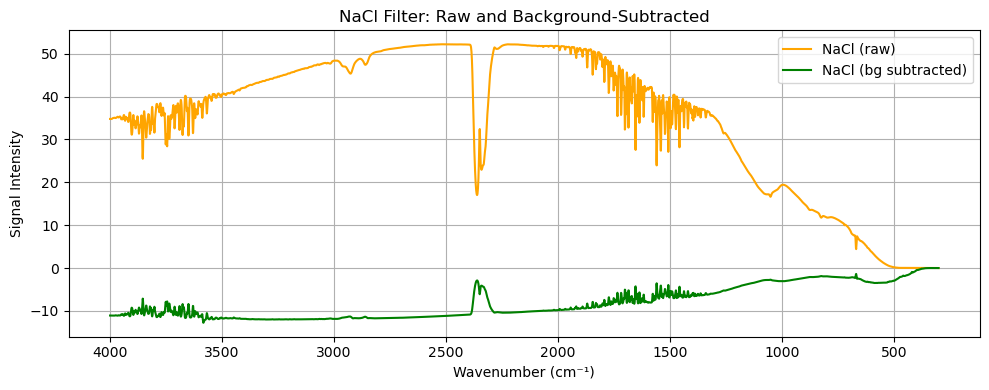

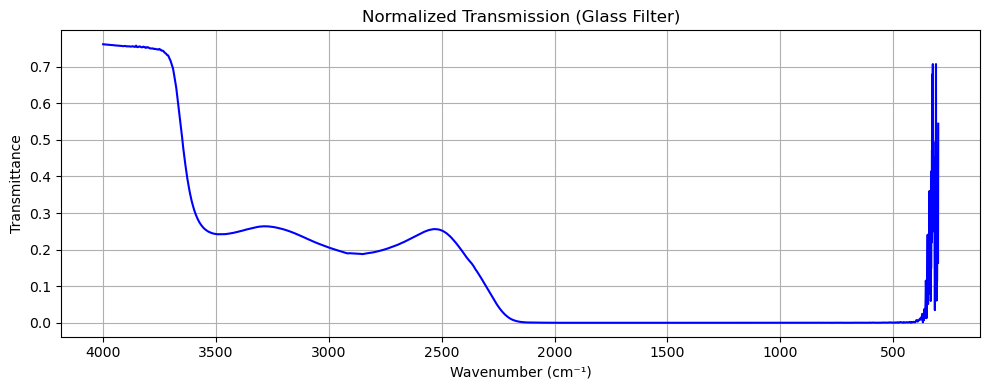

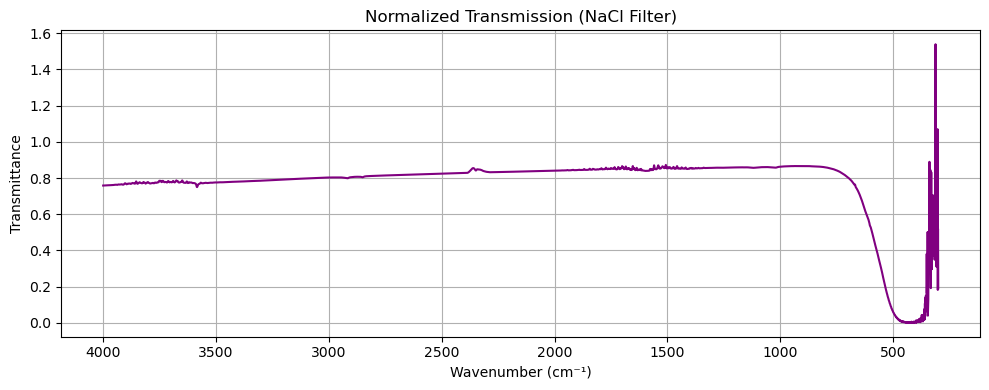

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Read .ASC files ---
def read_spectrum(filepath):
    with open(filepath, encoding='utf-8') as f:
        lines = f.readlines()[25:]
    data = []
    for line in lines:
        matches = re.findall(r"\d+,\d+", line)
        if len(matches) >= 2:
            try:
                wn = float(matches[0].replace(",", "."))
                intensity = float(matches[1].replace(",", "."))
                data.append((wn, intensity))
            except ValueError:
                continue
    return pd.DataFrame(data, columns=["Wavenumber", "Intensity"])

# --- Load data ---
df_glass = read_spectrum("glass.ASC")
df_nacl = read_spectrum("NaCl blocking filter.ASC")
df_ref = read_spectrum("reference background.ASC")

# --- Interpolate reference to match wavenumbers if needed ---
df_ref_interp = df_ref.set_index("Wavenumber").reindex(df_glass["Wavenumber"]).interpolate(method="linear").reset_index()

# --- Background subtraction ---
df_glass["Subtracted"] = df_glass["Intensity"] - df_ref_interp["Intensity"]
df_nacl["Subtracted"] = df_nacl["Intensity"] - df_ref_interp["Intensity"]

# --- Normalized transmission ---
df_glass["Transmittance"] = df_glass["Intensity"] / df_ref_interp["Intensity"]
df_nacl["Transmittance"] = df_nacl["Intensity"] / df_ref_interp["Intensity"]

# --- Plot 1: Glass filter (original + background subtracted) ---
plt.figure(figsize=(10, 4))
plt.plot(df_glass["Wavenumber"], df_glass["Intensity"], label="Glass (raw)", color="orange")
plt.plot(df_glass["Wavenumber"], df_glass["Subtracted"], label="Glass (bg subtracted)", color="green")
plt.gca().invert_xaxis()
plt.title("Glass Filter: Raw and Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: NaCl filter (original + background subtracted) ---
plt.figure(figsize=(10, 4))
plt.plot(df_nacl["Wavenumber"], df_nacl["Intensity"], label="NaCl (raw)", color="orange")
plt.plot(df_nacl["Wavenumber"], df_nacl["Subtracted"], label="NaCl (bg subtracted)", color="green")
plt.gca().invert_xaxis()
plt.title("NaCl Filter: Raw and Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 3: Transmittance (Glass) ---
plt.figure(figsize=(10, 4))
plt.plot(df_glass["Wavenumber"], df_glass["Transmittance"], label="Glass Transmittance", color="blue")
plt.gca().invert_xaxis()
plt.title("Normalized Transmission (Glass Filter)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Transmittance")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 4: Transmittance (NaCl) ---
plt.figure(figsize=(10, 4))
plt.plot(df_nacl["Wavenumber"], df_nacl["Transmittance"], label="NaCl Transmittance", color="purple")
plt.gca().invert_xaxis()
plt.title("Normalized Transmission (NaCl Filter)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Transmittance")
plt.grid(True)
plt.tight_layout()
plt.show()


# Task 3 ---------------------------------------------------------------------------------------------------

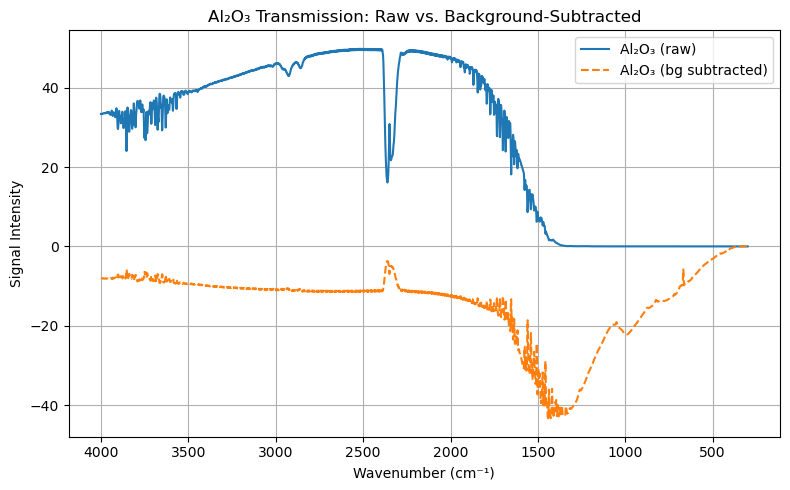

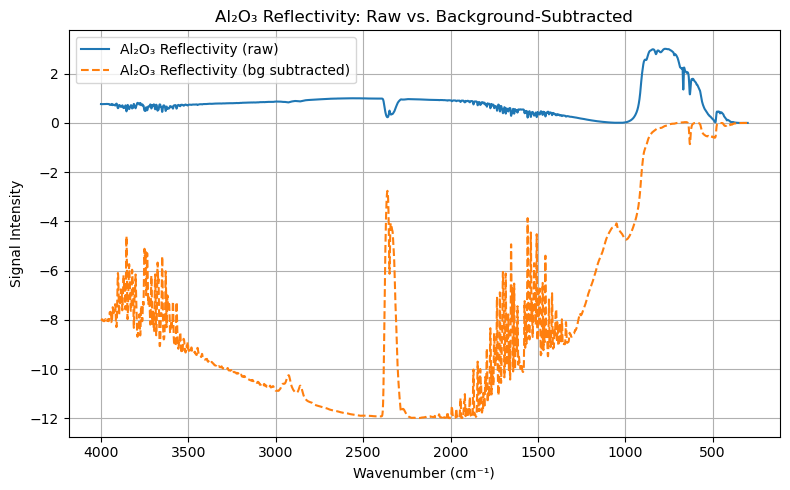

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Helper to read .ASC spectral data (skip header, parse comma decimals) ---
def read_spectrum(filepath):
    with open(filepath, encoding='utf-8') as f:
        lines = f.readlines()[25:]   # adjust if your header is longer/shorter
    data = []
    for line in lines:
        matches = re.findall(r"\d+,\d+", line)
        if len(matches) >= 2:
            wn = float(matches[0].replace(",", "."))
            intensity = float(matches[1].replace(",", "."))
            data.append((wn, intensity))
    return pd.DataFrame(data, columns=["Wavenumber", "Intensity"])

# --- File names (use raw-strings to avoid unicode escapes) ---
file_trans = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\Al2O3.ASC"
file_empty = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\Al2O3 empty.ASC"
file_ref   = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\REF Al2O3 .ASC"
file_back  = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\REF REFERENCE back.ASC"

# --- 1) Transmission: Al₂O₃ vs. empty cell ---
df_trans = read_spectrum(file_trans)
df_empty = read_spectrum(file_empty)

df_empty_interp = (
    df_empty.set_index("Wavenumber")
            .reindex(df_trans["Wavenumber"])
            .interpolate(method="linear")
            .reset_index()
)

df_trans["Subtracted"] = df_trans["Intensity"] - df_empty_interp["Intensity"]

plt.figure(figsize=(8,5))
plt.plot(df_trans["Wavenumber"], df_trans["Intensity"],      label="Al₂O₃ (raw)"          )
plt.plot(df_trans["Wavenumber"], df_trans["Subtracted"],     label="Al₂O₃ (bg subtracted)", linestyle="--")
plt.gca().invert_xaxis()
plt.title("Al₂O₃ Transmission: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --- 2) Reflection: Al₂O₃ vs. reference mirror ---
df_ref  = read_spectrum(file_ref)
df_back = read_spectrum(file_back)

df_back_interp = (
    df_back.set_index("Wavenumber")
           .reindex(df_ref["Wavenumber"])
           .interpolate(method="linear")
           .reset_index()
)

df_ref["Subtracted"] = df_ref["Intensity"] - df_back_interp["Intensity"]

plt.figure(figsize=(8,5))
plt.plot(df_ref["Wavenumber"], df_ref["Intensity"],      label="Al₂O₃ Reflectivity (raw)"          )
plt.plot(df_ref["Wavenumber"], df_ref["Subtracted"],     label="Al₂O₃ Reflectivity (bg subtracted)", linestyle="--")
plt.gca().invert_xaxis()
plt.title("Al₂O₃ Reflectivity: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


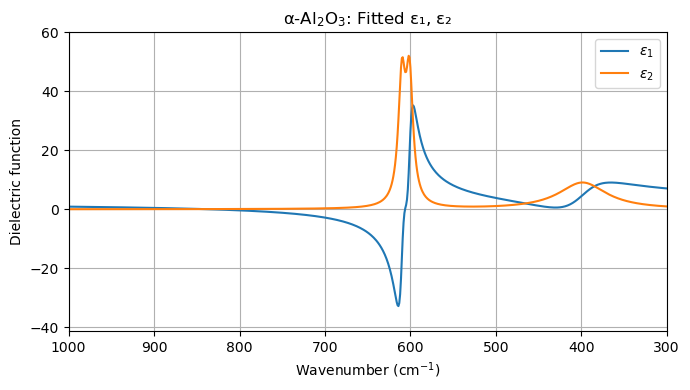

ε∞ = 2.00
B₁ = 500.0, ν₁ = 400.0 cm⁻¹, b₁ = 69.1 cm⁻¹
B₂ = 500.0, ν₂ = 601.1 cm⁻¹, b₂ = 10.0 cm⁻¹
B₃ = 500.0, ν₃ = 610.0 cm⁻¹, b₃ = 10.0 cm⁻¹


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit

# 1) Helper to read & subtract background
def read_spectrum(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m)>=2:
            wn.append(float(m[0].replace(',','.')))
            I.append(float(m[1].replace(',','.')))
    return np.array(wn), np.array(I)

# === update these paths ===
REF_SAMPLE = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\REF Al2O3 .ASC"
REF_BACK   = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\REF REFERENCE back.ASC"

wn_s, I_s = read_spectrum(REF_SAMPLE)
wn_b, I_b = read_spectrum(REF_BACK)

# subtract & clip reflectance, only keep >0
R = I_s - np.interp(wn_s, wn_b, I_b)
R = np.clip(R, 0, 1)

# restrict to the “good” interval 300–1200 cm⁻¹
mask = (wn_s >= 300) & (wn_s <= 1200)
nu = wn_s[mask]
R_fit = R[mask]

# 2) 3-oscillator dielectric model in Bj notation
def eps_3osc_B(nu, eps_inf,
               B1, nu1, b1,
               B2, nu2, b2,
               B3, nu3, b3):
    eps = eps_inf
    for B, nu_j, bj in ((B1,nu1,b1),(B2,nu2,b2),(B3,nu3,b3)):
        denom = (nu_j**2 - nu**2) - 1j*(bj*nu)
        eps += B**2 / denom
    return eps

def R_model(nu, *p):
    eps = eps_3osc_B(nu, *p)
    n = np.sqrt(eps)
    r = (1 - n)/(1 + n)
    return np.abs(r)**2

# 3) Initial guesses & bounds (literature TO’s: 377,574,647cm⁻¹)
p0 = [
    3.2,            # eps_inf
    100, 377, 30,   # B1, nu1, b1
    200, 574, 40,   # B2, nu2, b2
    150, 647, 50    # B3, nu3, b3
]

lower = [
    2.0,
    0,  350, 10,
    0,  540, 10,
    0,  610, 10
]
upper = [
    5.0,
    500, 400,  80,
    500, 610,  80,
    500, 700,  80
]

popt, pcov = curve_fit(
    R_model, nu, R_fit,
    p0=p0, bounds=(lower,upper),
    max_nfev=20000
)

(eps_inf, B1,nu1,b1,
       B2,nu2,b2,
       B3,nu3,b3) = popt

# Determine data range
y_min = min(eps_fit.real.min(), eps_fit.imag.min())
y_max = max(eps_fit.real.max(), eps_fit.imag.max())
# Add a 10% margin
dy = y_max - y_min
y_lo = y_min - 0.1*dy
y_hi = y_max + 0.1*dy

# And clamp to your desired “nice” limits if you like
y_lo = max(y_lo, -60)
y_hi = min(y_hi,  60)

# Now plot with explicit x‐ and y‐limits
plt.figure(figsize=(7,4))
plt.plot(nu, eps_fit.real, label=r'$\varepsilon_1$')
plt.plot(nu, eps_fit.imag, label=r'$\varepsilon_2$')
plt.gca().invert_xaxis()
plt.xlim(1000, nu.min())  # e.g. 1200 → 300
plt.ylim(y_lo, y_hi)
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Dielectric function")
plt.title("α-Al$_2$O$_3$: Fitted ε₁, ε₂")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5) Report parameters
print(f"ε∞ = {eps_inf:.2f}")
print(f"B₁ = {B1:.1f}, ν₁ = {nu1:.1f} cm⁻¹, b₁ = {b1:.1f} cm⁻¹")
print(f"B₂ = {B2:.1f}, ν₂ = {nu2:.1f} cm⁻¹, b₂ = {b2:.1f} cm⁻¹")
print(f"B₃ = {B3:.1f}, ν₃ = {nu3:.1f} cm⁻¹, b₃ = {b3:.1f} cm⁻¹")


Found 23 fringes; Δν = 8.82 ± 3.82 cm⁻¹
Thickness d = 1/(2Δν) = 0.0567 cm = 567.0 µm


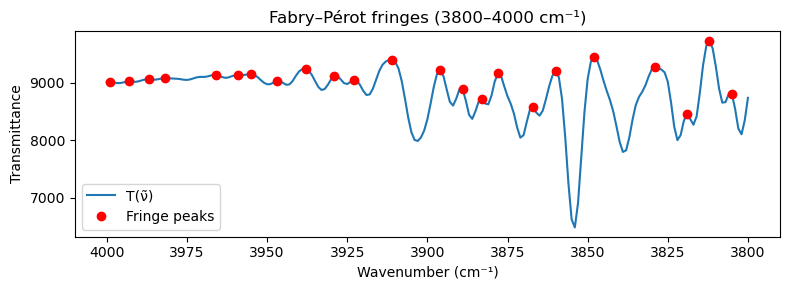

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.signal import find_peaks

# 1) Read & background‐correct transmission
def read_spectrum(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn.append(float(m[0].replace(',','.')))
            I.append(float(m[1].replace(',','.')))
    return np.array(wn), np.array(I)

# — update these paths —
SAMP = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\Al2O3.ASC"
BG   = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\Al2O3 empty.ASC"


wn_s, I_s = read_spectrum(SAMP)
wn_b, I_b = read_spectrum(BG)

# 2) Compute normalized transmittance
I_bi = np.interp(wn_s, wn_b, I_b)
T = I_s / I_bi

# 3) Sort ascending and restrict to 3800–4000 cm⁻¹
order   = np.argsort(wn_s)
wn_sort = wn_s[order]
T_sort  = T[order]
mask    = (wn_sort >= 3800) & (wn_sort <= 4000)
nu      = wn_sort[mask]
Tnu     = T_sort[mask]

# 4) Find fringe peaks
peaks, _ = find_peaks(Tnu, distance=4)
nu_peaks = nu[peaks]

# 5) Calculate Δν and thickness using d = 1/(2 Δν)
dnu     = np.diff(nu_peaks)
Delta_nu = np.mean(dnu)
sigma    = np.std(dnu)

d_cm = 1.0 / (2 * Delta_nu)
d_um = d_cm * 1e4

print(f"Found {len(nu_peaks)} fringes; Δν = {Delta_nu:.2f} ± {sigma:.2f} cm⁻¹")
print(f"Thickness d = 1/(2Δν) = {d_cm:.4f} cm = {d_um:.1f} µm")

# 6) Plot for verification
plt.figure(figsize=(8,3))
plt.plot(nu, Tnu,      label="T(ν̃)")
plt.plot(nu_peaks, Tnu[peaks], "ro", label="Fringe peaks")
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Transmittance")
plt.title("Fabry–Pérot fringes (3800–4000 cm⁻¹)")
plt.legend()
plt.tight_layout()
plt.show()


# task 4 --------------------------------------------------------------------------------------------------

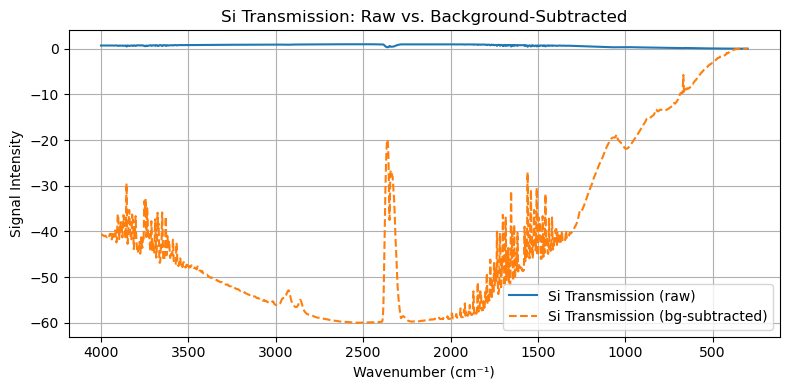

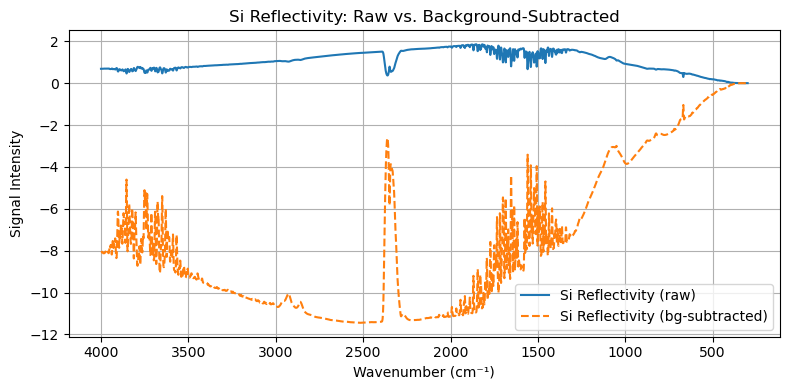

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# ——— helper to read a Bruker-style .ASC file ———
def read_spectrum(path, header=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[header:]
    data = []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn = float(m[0].replace(',', '.'))
            I  = float(m[1].replace(',', '.'))
            data.append((wn, I))
    return pd.DataFrame(data, columns=["Wavenumber", "Intensity"])

# ——— file paths ———
trans_file    = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\silicon trans.ASC"
empty_file    = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\silicon empty.ASC"
refl_file     = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\reflection Silicon.ASC"
refl_backfile = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\REF REFERENCE back.ASC"

# ——— 1) Transmission: raw vs. empty‐cell background ———
df_T     = read_spectrum(trans_file)
df_empty = read_spectrum(empty_file)

# interpolate empty onto the sample wavenumber grid
df_empty_i = (
    df_empty.set_index("Wavenumber")
            .reindex(df_T["Wavenumber"])
            .interpolate(method="linear")
            .reset_index()
)

# subtract
df_T["Subtracted"] = df_T["Intensity"] - df_empty_i["Intensity"]

# plot
plt.figure(figsize=(8,4))
plt.plot(df_T["Wavenumber"], df_T["Intensity"],    label="Si Transmission (raw)")
plt.plot(df_T["Wavenumber"], df_T["Subtracted"],   label="Si Transmission (bg-subtracted)", linestyle="--")
plt.gca().invert_xaxis()
plt.title("Si Transmission: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ——— 2) Reflection: raw vs. reference mirror background ———
df_R     = read_spectrum(refl_file)
df_rback = read_spectrum(refl_backfile)

df_rback_i = (
    df_rback.set_index("Wavenumber")
             .reindex(df_R["Wavenumber"])
             .interpolate(method="linear")
             .reset_index()
)

df_R["Subtracted"] = df_R["Intensity"] - df_rback_i["Intensity"]

plt.figure(figsize=(8,4))
plt.plot(df_R["Wavenumber"], df_R["Intensity"],    label="Si Reflectivity (raw)")
plt.plot(df_R["Wavenumber"], df_R["Subtracted"],   label="Si Reflectivity (bg-subtracted)", linestyle="--")
plt.gca().invert_xaxis()
plt.title("Si Reflectivity: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


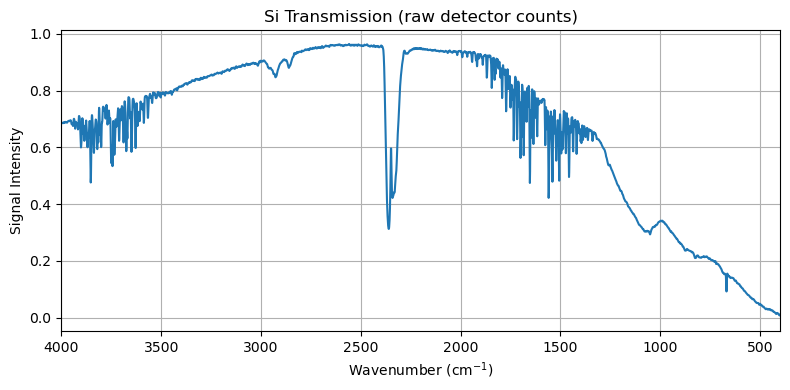

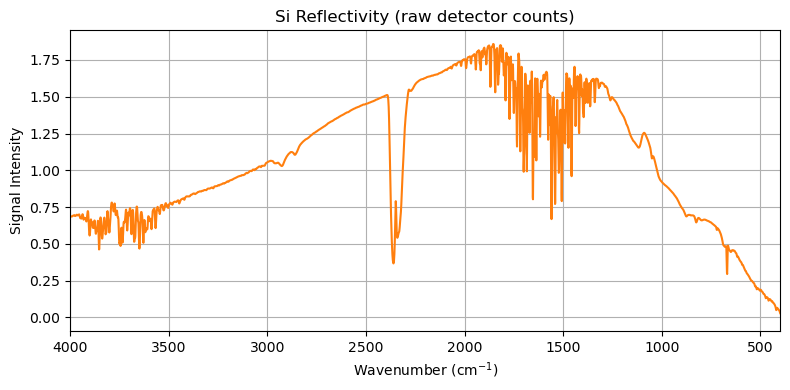

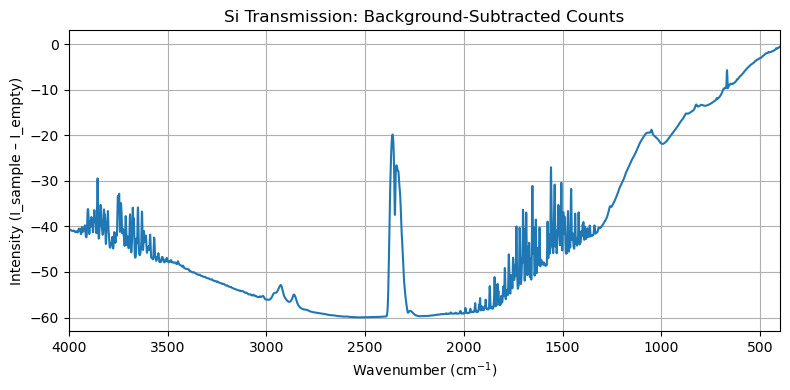

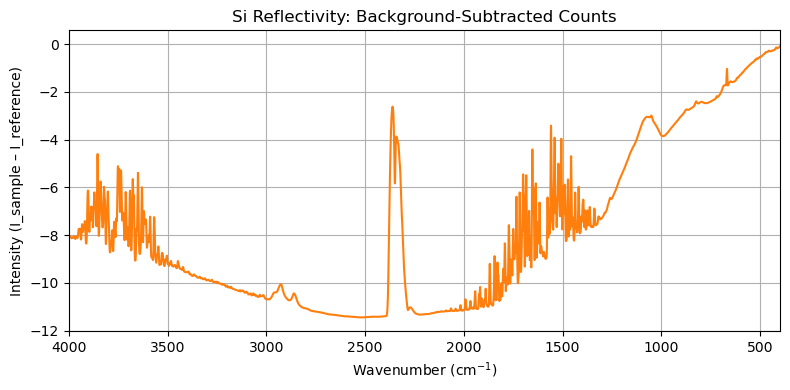

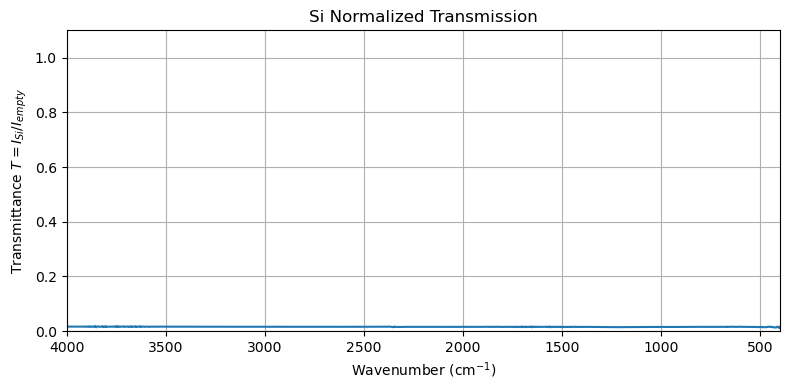

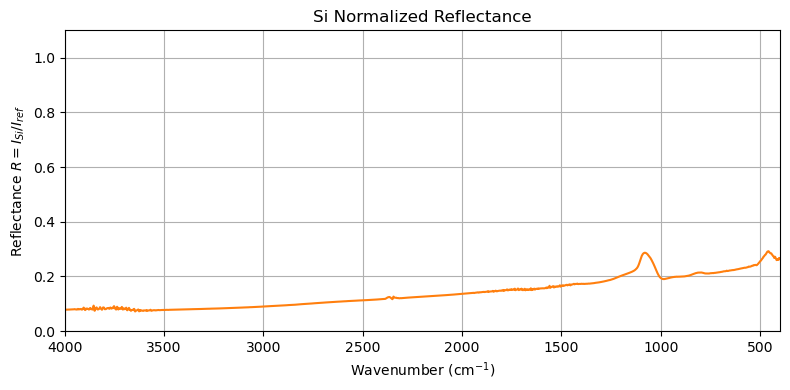

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

# — helper to read a Bruker-style .ASC file —
def read_spectrum(path, header=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[header:]
    data = []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn = float(m[0].replace(',', '.'))
            I  = float(m[1].replace(',', '.'))
            data.append((wn, I))
    return pd.DataFrame(data, columns=["Wavenumber", "Intensity"])

# — file paths —
trans_file    = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\silicon trans.ASC"
empty_file    = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\silicon empty.ASC"
refl_file     = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\reflection Silicon.ASC"
refl_backfile = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\REF REFERENCE back.ASC"

# — 1) Load raw spectra —
df_T     = read_spectrum(trans_file)
df_empty = read_spectrum(empty_file)

df_R     = read_spectrum(refl_file)
df_ref   = read_spectrum(refl_backfile)

# — 2) Interpolate backgrounds onto each grid —
df_empty_i = (df_empty.set_index("Wavenumber")
                       .reindex(df_T["Wavenumber"])
                       .interpolate()
                       .reset_index())

df_ref_i   = (df_ref.set_index("Wavenumber")
                     .reindex(df_R["Wavenumber"])
                     .interpolate()
                     .reset_index())
# — Raw Transmission and Reflection Plots —

# 1) Raw Transmission
plt.figure(figsize=(8,4))
plt.plot(df_T["Wavenumber"], df_T["Intensity"], color="tab:blue")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.title("Si Transmission (raw detector counts)")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Signal Intensity")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Raw Reflection
plt.figure(figsize=(8,4))
plt.plot(df_R["Wavenumber"], df_R["Intensity"], color="tab:orange")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.title("Si Reflectivity (raw detector counts)")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Signal Intensity")
plt.grid(True)
plt.tight_layout()
plt.show()
 # — Background‐subtracted “raw” data plots — 

# Transmission: raw minus empty
df_T["BgSub"] = df_T["Intensity"] - df_empty_i["Intensity"]
plt.figure(figsize=(8,4))
plt.plot(df_T["Wavenumber"], df_T["BgSub"], color="tab:blue")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.title("Si Transmission: Background‐Subtracted Counts")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Intensity (I_sample – I_empty)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Reflection: raw minus reference
df_R["BgSub"] = df_R["Intensity"] - df_ref_i["Intensity"]
plt.figure(figsize=(8,4))
plt.plot(df_R["Wavenumber"], df_R["BgSub"], color="tab:orange")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.title("Si Reflectivity: Background‐Subtracted Counts")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Intensity (I_sample – I_reference)")
plt.grid(True)
plt.tight_layout()
plt.show()

# — 3) Compute normalized T and R —
df_T["Transmittance"] = np.clip(df_T["Intensity"] / df_empty_i["Intensity"], 0, 1)
df_R["Reflectance"]    = np.clip(df_R["Intensity"] / df_ref_i["Intensity"],   0, 1)

# — 4) Plot Transmittance —
plt.figure(figsize=(8,4))
plt.plot(df_T["Wavenumber"], df_T["Transmittance"], color="tab:blue")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(0, 1.1)
plt.title("Si Normalized Transmission")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Transmittance $T = I_{Si}/I_{empty}$")
plt.grid(True)
plt.tight_layout()
plt.show()

# — 5) Plot Reflectance —
plt.figure(figsize=(8,4))
plt.plot(df_R["Wavenumber"], df_R["Reflectance"], color="tab:orange")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(0, 1.1)
plt.title("Si Normalized Reflectance")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Reflectance $R = I_{Si}/I_{ref}$")
plt.grid(True)
plt.tight_layout()
plt.show()


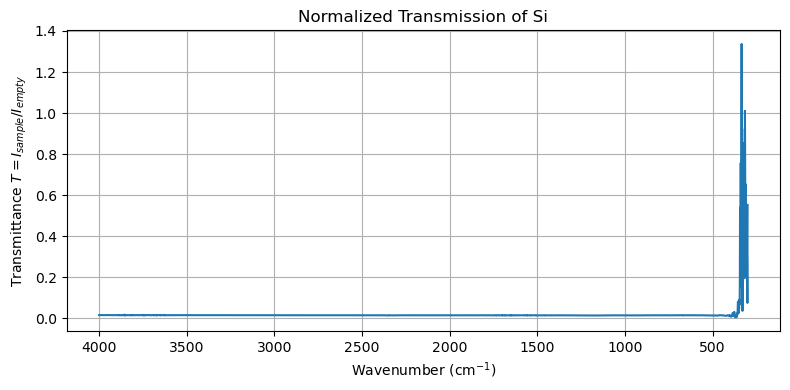

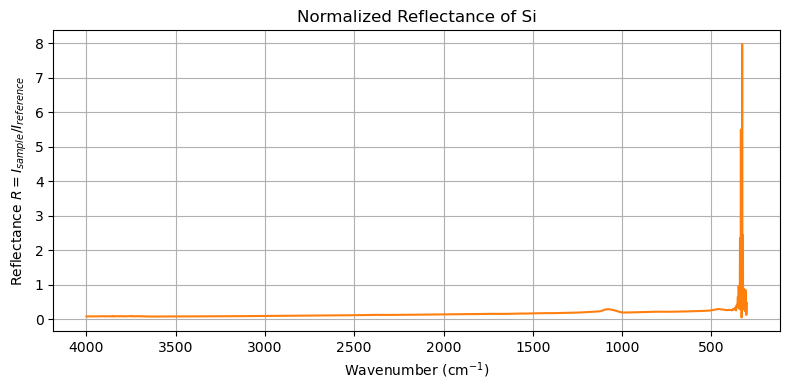

In [31]:

# — 1) Read dataframes —
df_T     = read_spectrum(trans_file)
df_empty = read_spectrum(empty_file)

df_R     = read_spectrum(refl_file)
df_back  = read_spectrum(refl_backfile)

# — 2) Interpolate backgrounds onto each measurement’s wavenumber grid —
df_empty_i = (df_empty.set_index("Wavenumber")
                        .reindex(df_T["Wavenumber"])
                        .interpolate()
                        .reset_index())
df_back_i  = (df_back.set_index("Wavenumber")
                       .reindex(df_R["Wavenumber"])
                       .interpolate()
                       .reset_index())

# — 3) Compute normalized transmission & reflection —
df_T["Transmittance"] = df_T["Intensity"] / df_empty_i["Intensity"]
df_R["Reflectance"]   = df_R["Intensity"] / df_back_i["Intensity"]

# — 4) Plot normalized transmission —
plt.figure(figsize=(8,4))
plt.plot(df_T["Wavenumber"], df_T["Transmittance"], color="tab:blue")
plt.gca().invert_xaxis()
plt.title("Normalized Transmission of Si")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Transmittance $T = I_{sample}/I_{empty}$")
plt.grid(True)
plt.tight_layout()
plt.show()

# — 5) Plot normalized reflection —
plt.figure(figsize=(8,4))
plt.plot(df_R["Wavenumber"], df_R["Reflectance"], color="tab:orange")
plt.gca().invert_xaxis()
plt.title("Normalized Reflectance of Si")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Reflectance $R = I_{sample}/I_{reference}$")
plt.grid(True)
plt.tight_layout()
plt.show()

Fitted parameters:
 ε∞ = 5.00
 ωₚ = 8.46e+15 rad/s
 γ  = 2.56e+13 rad/s


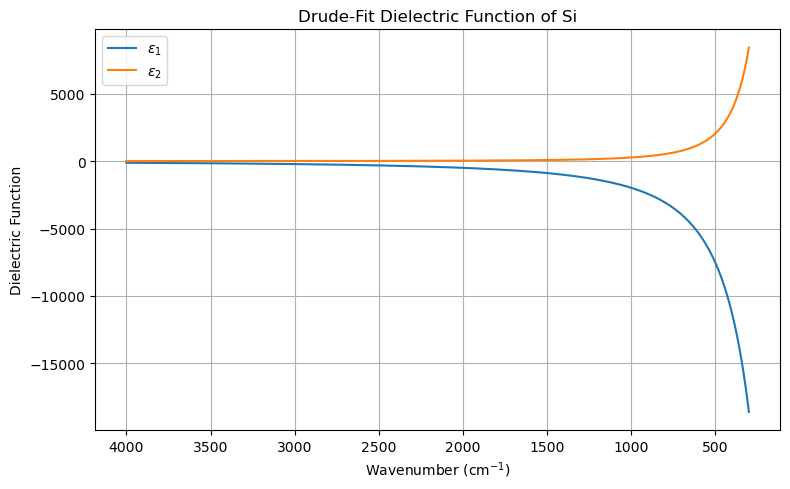

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit

# 1) Read & normalize Reflectance
def read_spectrum(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn.append(float(m[0].replace(',', '.')))
            I.append(float(m[1].replace(',', '.')))
    return np.array(wn), np.array(I)

# — adjust these paths as needed —
REF_SI     = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\reflection Silicon.ASC"
REF_BACK   = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\REF REFERENCE back.ASC"

wn_s, I_s = read_spectrum(REF_SI)
wn_b, I_b = read_spectrum(REF_BACK)

# Interpolate background onto sample grid and normalize
I_bi = np.interp(wn_s, wn_b, I_b)
R = np.clip(I_s / I_bi, 0, 1)

# 2) Convert wavenumber (cm⁻¹) → angular frequency (rad/s)
c_cm = 2.99792458e10  # speed of light in cm/s
omega = 2 * np.pi * c_cm * wn_s

# 3) Drude dielectric & reflectance models
def eps_drude(omega, eps_inf, omega_p, gamma):
    return eps_inf - omega_p**2 / (omega**2 + 1j*gamma*omega)

def R_drude(omega, eps_inf, omega_p, gamma):
    eps = eps_drude(omega, eps_inf, omega_p, gamma)
    n = np.sqrt(eps)
    r = (n - 1) / (n + 1)
    return np.abs(r)**2

# 4) Fit to data
# initial guesses: ε∞~11.7 (Si high-frequency), ω_p~1e16 (rad/s), γ~1e14
p0 = [11.7, 1e16, 1e14]
bounds = ([5, 1e15, 1e13], [20, 5e16, 5e14])

popt, pcov = curve_fit(R_drude, omega, R, p0=p0, bounds=bounds, max_nfev=10000)
eps_inf_fit, omega_p_fit, gamma_fit = popt

print(f"Fitted parameters:\n ε∞ = {eps_inf_fit:.2f}\n ωₚ = {omega_p_fit:.2e} rad/s\n γ  = {gamma_fit:.2e} rad/s")

# 5) Compute ε(ω) on the original grid and convert ω back to wn for plotting
eps_fit = eps_drude(omega, *popt)
wn = wn_s  # cm⁻¹

# 6) Plot ε1 and ε2 vs wavenumber
plt.figure(figsize=(8,5))
plt.plot(wn, eps_fit.real, label=r'$\varepsilon_1$')
plt.plot(wn, eps_fit.imag, label=r'$\varepsilon_2$')
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Dielectric Function")
plt.title("Drude‐Fit Dielectric Function of Si")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


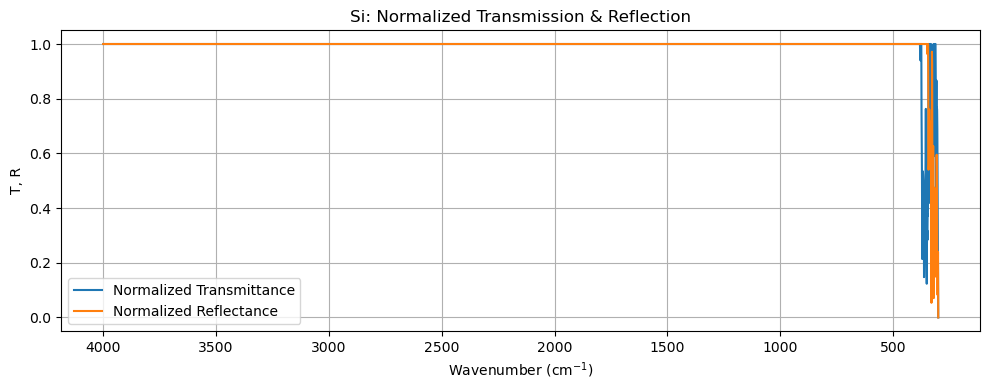

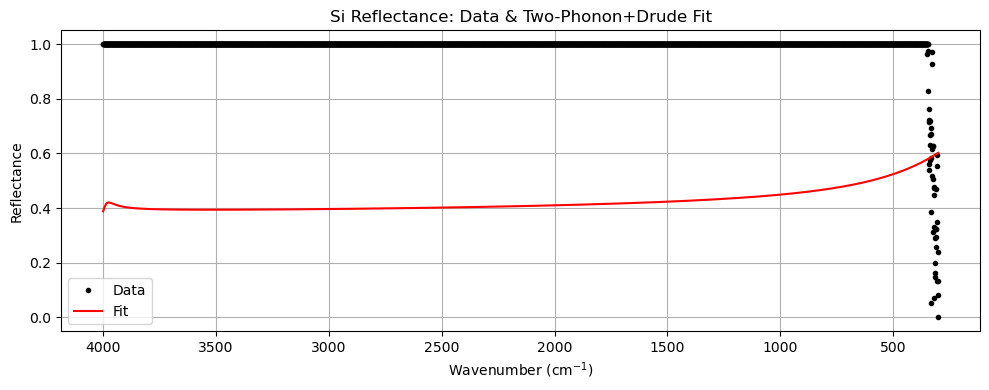

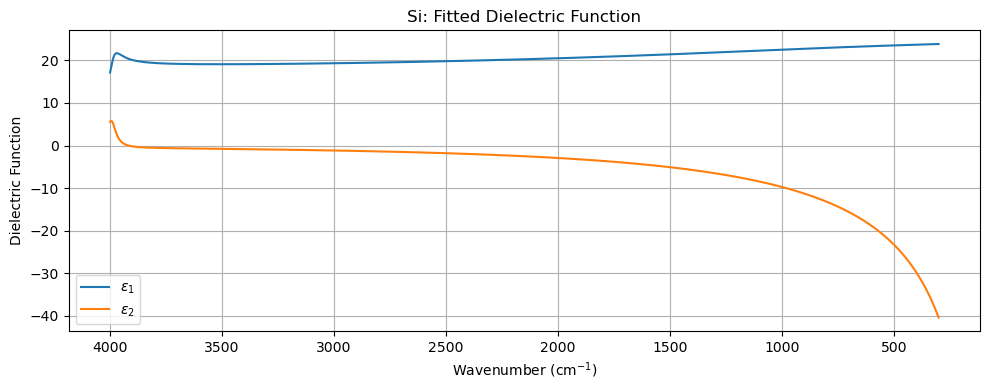

ε∞   = 17.266
B₁   = 1115.400
ν₁   = 3994.700
b₁   = 48.950
B₂   = 1000.000
ν₂   = 131.900
b₂   = 1239.750
ν_p  = 4935.300
b_e  = 1841.600


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit

# 1) Reader for Bruker .ASC files
def read_asc(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn.append(float(m[0].replace(',', '.')))
            I.append(float(m[1].replace(',', '.')))
    return np.array(wn), np.array(I)

# 2) File locations (your folder)
BASE = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration"
# Transmission
wn_T, I_T    = read_asc(f"{BASE}\\silicon trans.ASC")
wn_empty, I_empty = read_asc(f"{BASE}\\silicon empty.ASC")
# Reflection
wn_R, I_R    = read_asc(f"{BASE}\\reflection Silicon.ASC")
wn_ref, I_ref = read_asc(f"{BASE}\\REF REFERENCE back.ASC")

# 3) Normalize
I_empty_i = np.interp(wn_T, wn_empty, I_empty)
T = np.clip(I_T / I_empty_i, 0, 1)

I_ref_i = np.interp(wn_R, wn_ref, I_ref)
R = np.clip(I_R / I_ref_i, 0, 1)

# 4) Plot normalized transmission & reflection
plt.figure(figsize=(10,4))
plt.plot(wn_T, T, label="Normalized Transmittance", color="tab:blue")
plt.plot(wn_R, R, label="Normalized Reflectance",  color="tab:orange")
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("T, R")
plt.title("Si: Normalized Transmission & Reflection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5) Two-phonon + Drude dielectric model (Task 4) :contentReference[oaicite:1]{index=1}
def eps_si(nu, eps_inf,
           B1, nu1, b1,
           B2, nu2, b2,
           nu_p, b_e):
    eps = eps_inf
    eps += B1**2 / (nu1**2 - nu**2 - 1j*b1*nu)
    eps += B2**2 / (nu2**2 - nu**2 - 1j*b2*nu)
    eps += nu_p**2 / (nu**2 + 1j*b_e*nu)
    return eps

def R_model(nu, *p):
    eps = eps_si(nu, *p)
    n    = np.sqrt(eps)
    r    = (1 - n)/(1 + n)
    return np.abs(r)**2

# 6) Initial guesses & bounds from Table 4 :contentReference[oaicite:2]{index=2}
p0 = [
    11.511,    # ε∞
    743.6, 4011.9, 97.9,   # B1, ν1, b1
    2000.0, 263.8, 826.5,  # B2, ν2, b2
    3290.2, 3683.2         # ν_p, b_e
]
# Allow ±20% variation
lower = [x*0.5 for x in p0]
upper = [x*1.5 for x in p0]

popt, pcov = curve_fit(
    R_model,
    wn_R, R,
    p0=p0,
    bounds=(lower, upper),
    max_nfev=20000
)

# 7) Overlay fit
R_fit = R_model(wn_R, *popt)
plt.figure(figsize=(10,4))
plt.plot(wn_R, R,    'k.', label="Data")
plt.plot(wn_R, R_fit, 'r-', label="Fit")
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Reflectance")
plt.title("Si Reflectance: Data & Two-Phonon+Drude Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 8) Plot ε₁ and ε₂
eps_fit = eps_si(wn_R, *popt)
plt.figure(figsize=(10,4))
plt.plot(wn_R, eps_fit.real, label=r'$\varepsilon_1$')
plt.plot(wn_R, eps_fit.imag, label=r'$\varepsilon_2$')
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Dielectric Function")
plt.title("Si: Fitted Dielectric Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 9) Print fitted parameters
names = ["ε∞","B₁","ν₁","b₁","B₂","ν₂","b₂","ν_p","b_e"]
for n,val in zip(names, popt):
    print(f"{n:<4} = {val:.3f}")


# Task 5 ----------------------------------------------------------------------------------------------------

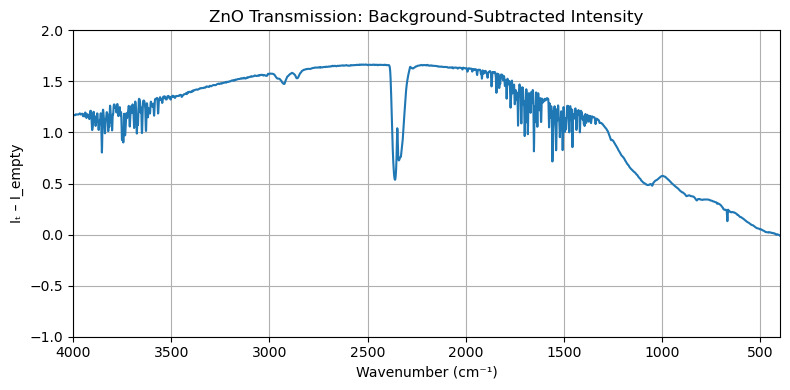

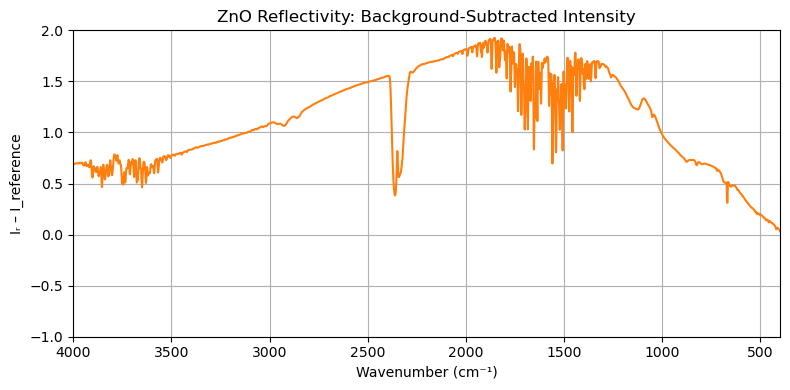

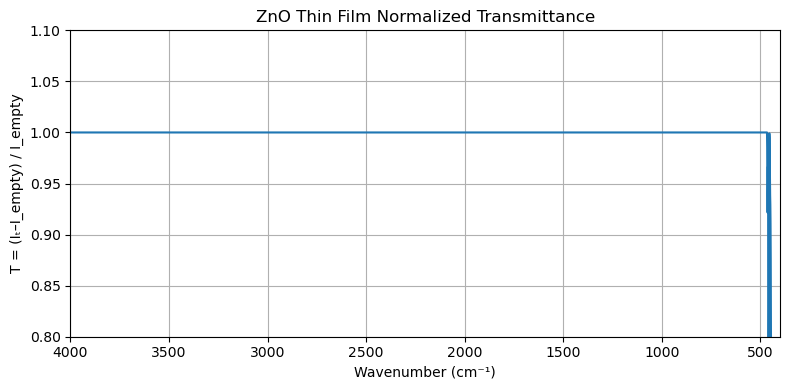

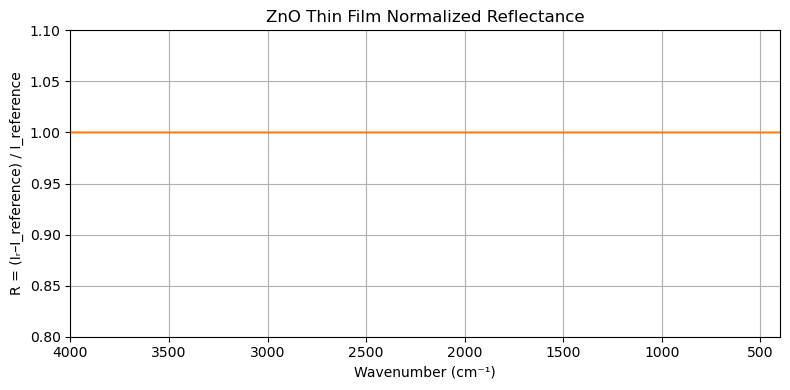

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import re

# — helper to read a Bruker‐style .ASC file —
def read_asc(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn.append(float(m[0].replace(",", ".")))
            I.append(float(m[1].replace(",", ".")))
    return np.array(wn), np.array(I)

# — base folder for your files —
BASE = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration"

# 1) Load & subtract backgrounds
# Transmission
wn_t, I_t          = read_asc(f"{BASE}\\ZnO transmitted.ASC")
wn_empty, I_empty  = read_asc(f"{BASE}\\znO incident empty.ASC")
I_empty_i          = np.interp(wn_t, wn_empty, I_empty)
I_t_sub            = I_t - I_empty_i

# Reflection
wn_r, I_r                 = read_asc(f"{BASE}\\ZnO reflected.ASC")
wn_ref_inc, I_ref_inc     = read_asc(f"{BASE}\\ZnO reflected incident..ASC")
I_ref_i                   = np.interp(wn_r, wn_ref_inc, I_ref_inc)
I_r_sub                   = I_r - I_ref_i

# 2) Plot background-subtracted intensities
plt.figure(figsize=(8,4))
plt.plot(wn_t, I_t_sub, label="Transmission Intensity", color="tab:blue")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(-1, 2)
plt.title("ZnO Transmission: Background-Subtracted Intensity")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Iₜ – I_empty")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(wn_r, I_r_sub, label="Reflectance Intensity", color="tab:orange")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(-1, 2)
plt.title("ZnO Reflectivity: Background-Subtracted Intensity")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Iᵣ – I_reference")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Compute normalized T and R
T = np.clip(I_t_sub / I_empty_i, 0, 1)
R = np.clip(I_r_sub / I_ref_i,   0, 1)

# 4) Plot normalized spectra
plt.figure(figsize=(8,4))
plt.plot(wn_t, T, label="Normalized Transmittance", color="tab:blue")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(0.8, 1.1)
plt.title("ZnO Thin Film Normalized Transmittance")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("T = (Iₜ–I_empty) / I_empty")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(wn_r, R, label="Normalized Reflectance", color="tab:orange")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(0.8, 1.1)
plt.title("ZnO Thin Film Normalized Reflectance")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("R = (Iᵣ–I_reference) / I_reference")
plt.grid(True)
plt.tight_layout()
plt.show()


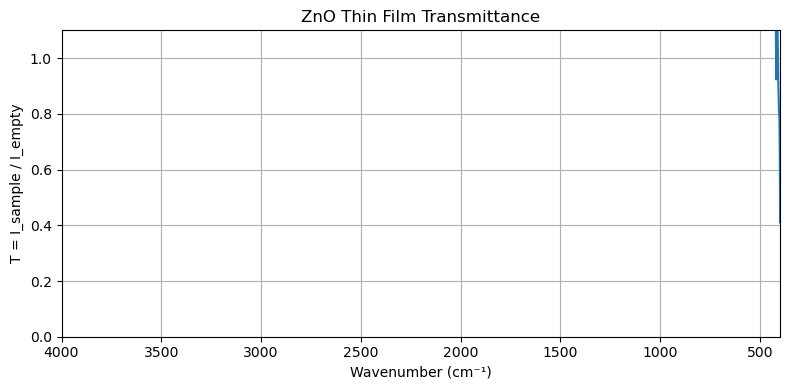

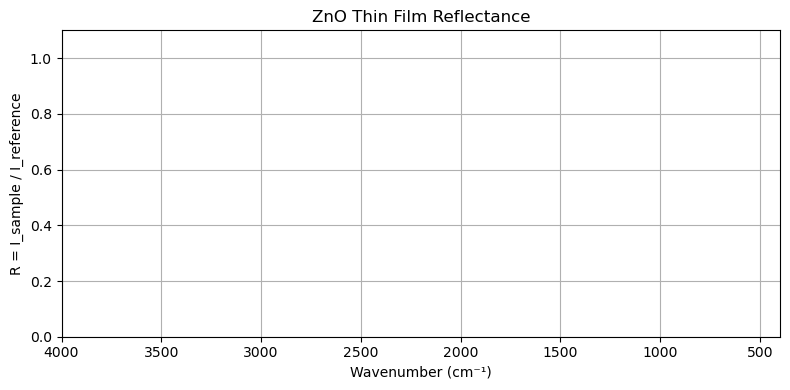

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import re

# — helper to read a Bruker‐style .ASC file —
def read_asc(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn.append(float(m[0].replace(",", ".")))
            I.append(float(m[1].replace(",", ".")))
    return np.array(wn), np.array(I)

# — base folder for your files —
BASE = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration"

# 1) Load & subtract backgrounds

# Transmission
wn_t, I_t         = read_asc(f"{BASE}\\ZnO transmitted.ASC")
wn_empty, I_empty = read_asc(f"{BASE}\\znO incident empty.ASC")
I_empty_i         = np.interp(wn_t, wn_empty, I_empty)
I_t_sub           = I_t - I_empty_i

# Reflection
wn_r, I_r               = read_asc(f"{BASE}\\ZnO reflected.ASC")
wn_ref_inc, I_ref_inc   = read_asc(f"{BASE}\\ZnO reflected incident..ASC")
I_ref_i                 = np.interp(wn_r, wn_ref_inc, I_ref_inc)
I_r_sub                 = I_r - I_ref_i

# 2) Compute T and R from the subtracted data:
#    T = I_sample / I_empty  ==> I_sample = I_t_sub + I_empty_i
#    => T = (I_t_sub + I_empty_i) / I_empty_i = 1 + I_t_sub/I_empty_i
# same for R
T = 1 + I_t_sub / I_empty_i
R = 1 + I_r_sub / I_ref_i

# 3) Plot Transmittance
plt.figure(figsize=(8,4))
plt.plot(wn_t, T, color="tab:blue")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(0, 1.1)
plt.title("ZnO Thin Film Transmittance")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("T = I_sample / I_empty")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4) Plot Reflectance
plt.figure(figsize=(8,4))
plt.plot(wn_r, R, color="tab:orange")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(0, 1.1)
plt.title("ZnO Thin Film Reflectance")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("R = I_sample / I_reference")
plt.grid(True)
plt.tight_layout()
plt.show()


# Task 6

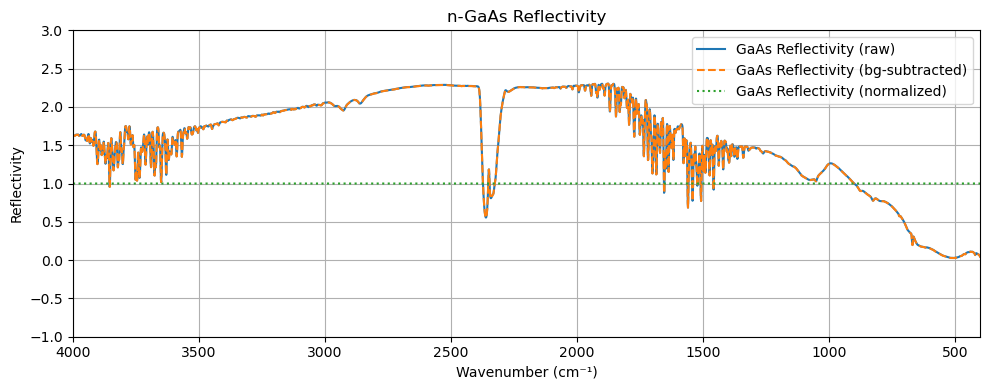

Fitted ε∞  = 20.00
Fitted ωₚ = 1.00e+15 rad/s
Fitted γ   = 1.00e+12 rad/s
Carrier concentration nₛ = 2.11e+19 cm⁻³


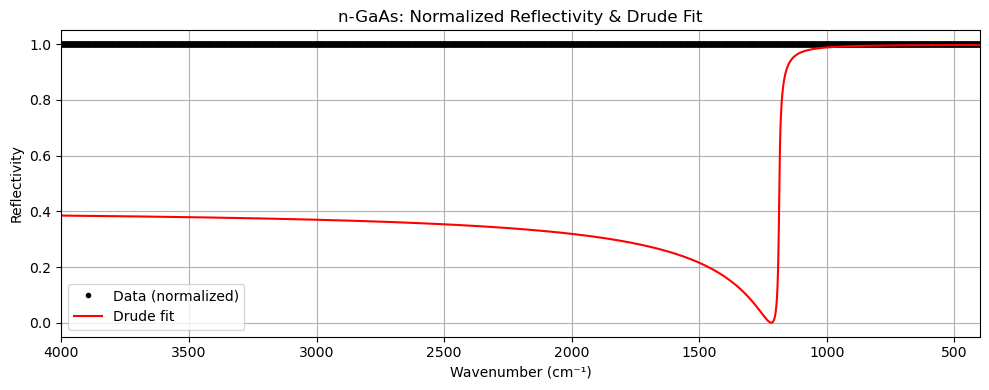

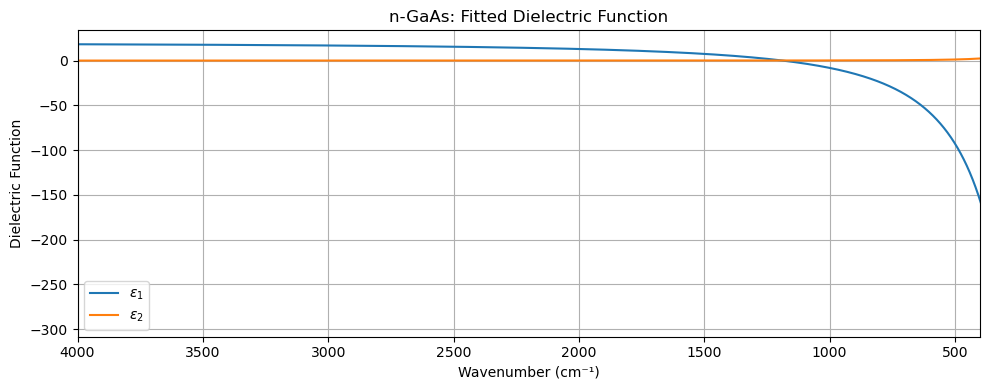

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit

# --- 1) Read & normalize GaAs reflectivity ---
def read_asc(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn.append(float(m[0].replace(',', '.')))
            I.append(float(m[1].replace(',', '.')))
    return np.array(wn), np.array(I)

BASE = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration"

# sample and background
wn_s, I_s = read_asc(f"{BASE}\\REF GaAs.ASC")
wn_b, I_b = read_asc(f"{BASE}\\GaAs incident back.ASC")

# interpolate background → sample grid
I_bi = np.interp(wn_s, wn_b, I_b)

# raw and background-subtracted
R_raw = I_s
R_sub = I_s - I_bi

# normalized reflectivity
R_norm = np.clip(I_s / I_bi, 0, 1)

# --- 2) Plot raw vs bg-subtracted vs normalized ---
plt.figure(figsize=(10,4))
plt.plot(wn_s, R_raw,  label="GaAs Reflectivity (raw)")
plt.plot(wn_s, R_sub,  label="GaAs Reflectivity (bg-subtracted)", linestyle="--")
plt.plot(wn_s, R_norm, label="GaAs Reflectivity (normalized)", linestyle=":")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(-1, 3)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectivity")
plt.title("n-GaAs Reflectivity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 3) Fit to Drude model to extract ωp and γ ---
# convert wn to ω [rad/s]
c_cm = 2.99792458e10
omega = 2 * np.pi * c_cm * wn_s

def eps_drude(ω, eps_inf, ω_p, γ):
    return eps_inf - ω_p**2 / (ω**2 + 1j*γ*ω)

def R_model(ω, eps_inf, ω_p, γ):
    eps = eps_drude(ω, eps_inf, ω_p, γ)
    n = np.sqrt(eps)
    r = (n - 1)/(n + 1)
    return np.abs(r)**2

# initial guesses and bounds
p0 = [12.0, 5e14, 1e13]
bounds = ([5.0, 1e14, 1e12], [20.0, 1e15, 5e13])

popt, pcov = curve_fit(R_model, omega, R_norm, p0=p0, bounds=bounds, max_nfev=10000)
eps_inf_fit, ωp_fit, γ_fit = popt

print(f"Fitted ε∞  = {eps_inf_fit:.2f}")
print(f"Fitted ωₚ = {ωp_fit:.2e} rad/s")
print(f"Fitted γ   = {γ_fit:.2e} rad/s")

# --- 4) Estimate carrier concentration ---
# ωp^2 = e^2 n_s / (ε0 m*)  →  n_s = ωp^2 ε0 m* / e^2
ε0 = 8.854e-12
e  = 1.602e-19
m0 = 9.109e-31
m_eff = 0.067 * m0  # GaAs conduction band effective mass
n_s = (ωp_fit**2 * ε0 * m_eff) / e**2
n_cm3 = n_s / 1e6  # convert to cm^-3

print(f"Carrier concentration nₛ = {n_cm3:.2e} cm⁻³")

# --- 5) Overlay fit on normalized data ---
R_fit = R_model(omega, *popt)
plt.figure(figsize=(10,4))
plt.plot(wn_s, R_norm, 'k.', label="Data (normalized)")
plt.plot(wn_s, R_fit, 'r-', label="Drude fit")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectivity")
plt.title("n-GaAs: Normalized Reflectivity & Drude Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 6) Plot fitted dielectric function ---
eps_fit = eps_drude(omega, *popt)
plt.figure(figsize=(10,4))
plt.plot(wn_s, eps_fit.real, label=r'$\varepsilon_1$')
plt.plot(wn_s, eps_fit.imag, label=r'$\varepsilon_2$')
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Dielectric Function")
plt.title("n-GaAs: Fitted Dielectric Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd

# --- 7) Tabulate fitted parameters ---
param_info = [
    ("ε∞",    "High‐frequency dielectric constant",                eps_inf_fit),
    ("ωₚ",    "Plasma frequency (rad/s)",                          ωp_fit),
    ("γ",     "Drude damping constant (rad/s)",                    γ_fit),
    ("nₛ",    "Carrier concentration (cm⁻³)",                      n_cm3),
]

df_results = pd.DataFrame(param_info, columns=["Parameter","Description","Value"])

# apply formatting: scientific notation for large/small, fixed‐point for ε∞
def fmt(val, param):
    if param == "ε∞":
        return f"{val:.2f}"
    else:
        return f"{val:.2e}"

df_results["Value"] = [fmt(v, p) for p,_,v in param_info]

print("\nn-GaAs Drude‐Model Fit Results\n")
print(df_results.to_string(index=False))



n-GaAs Drude‐Model Fit Results

Parameter                        Description    Value
       ε∞ High‐frequency dielectric constant    20.00
       ωₚ           Plasma frequency (rad/s) 1.00e+15
        γ     Drude damping constant (rad/s) 1.00e+12
       nₛ       Carrier concentration (cm⁻³) 2.11e+19


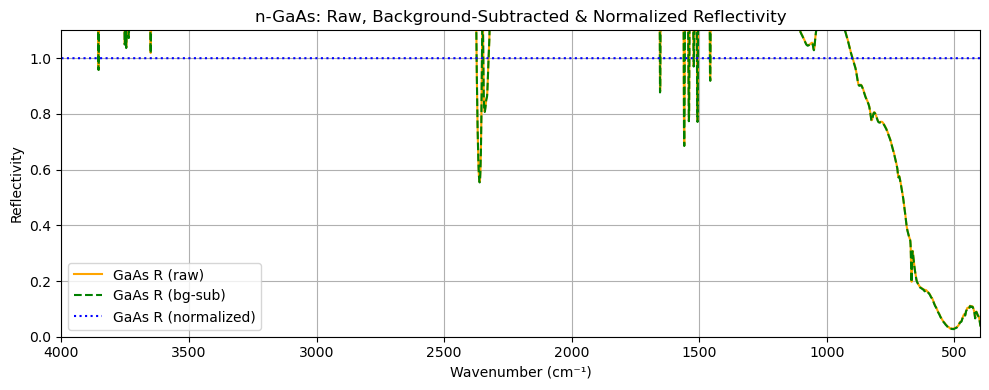


n-GaAs Drude Fit Parameters:

Parameter                        Description     Value
       ε∞ High-frequency dielectric constant 2.000e+01
       ωₚ           Plasma frequency (rad/s) 1.000e+15
        γ           Damping constant (rad/s) 1.000e+12


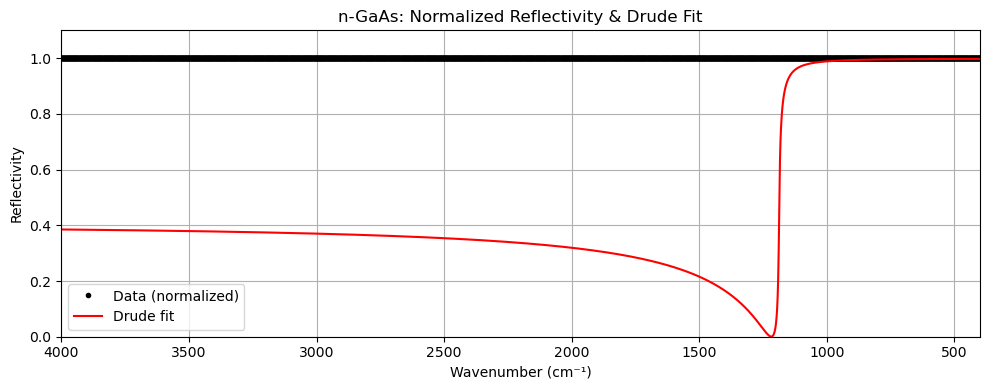

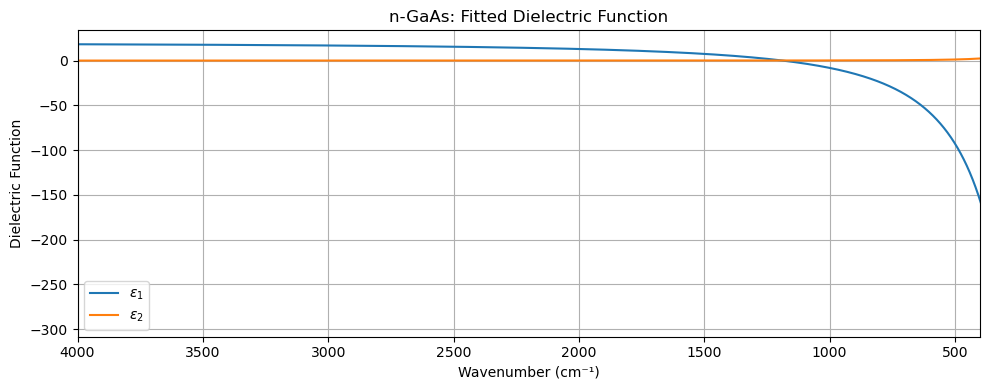

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit

# --- 1) Read .ASC files ---
def read_spectrum(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn.append(float(m[0].replace(',', '.')))
            I.append(float(m[1].replace(',', '.')))
    return np.array(wn), np.array(I)

BASE       = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration"
REF_FILE   = f"{BASE}\\REF GaAs.ASC"
BACK_FILE  = f"{BASE}\\GaAs incident back.ASC"

wn_s, I_s  = read_spectrum(REF_FILE)
wn_b, I_b  = read_spectrum(BACK_FILE)

# interpolate background onto sample grid
I_bi   = np.interp(wn_s, wn_b, I_b)

# background‐subtracted and normalized reflectivity
R_sub  = I_s - I_bi
R_norm = np.clip(R_sub / I_bi, 0, 1)

# --- 2) Plot raw vs bg-subtracted vs normalized ---
plt.figure(figsize=(10,4))
plt.plot(wn_s, I_s,    label="GaAs R (raw)", color="orange")
plt.plot(wn_s, R_sub,  label="GaAs R (bg-sub)", linestyle="--", color="green")
plt.plot(wn_s, R_norm, label="GaAs R (normalized)", linestyle=":", color="blue")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(0, 1.1)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectivity")
plt.title("n-GaAs: Raw, Background-Subtracted & Normalized Reflectivity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 3) Drude‐model fit ---
# convert wavenumber to angular frequency [rad/s]
c_cm  = 2.99792458e10
ω     = 2 * np.pi * c_cm * wn_s

def eps_drude(ω, eps_inf, ω_p, γ):
    return eps_inf - ω_p**2/(ω**2 + 1j*γ*ω)

def R_model(ω, eps_inf, ω_p, γ):
    eps = eps_drude(ω, eps_inf, ω_p, γ)
    n   = np.sqrt(eps)
    r   = (n - 1)/(n + 1)
    return np.abs(r)**2

p0     = [12.0, 5e14, 1e13]  # ε∞, ωp, γ
bounds = ([5.0, 1e14, 1e12], [20.0, 1e15, 5e13])

popt, _ = curve_fit(R_model, ω, R_norm, p0=p0, bounds=bounds, max_nfev=5000)
eps_inf_fit, ωp_fit, γ_fit = popt

# display fitted parameters
df_fit = pd.DataFrame([
    ("ε∞",   "High-frequency dielectric constant",   eps_inf_fit),
    ("ωₚ",   "Plasma frequency (rad/s)",             ωp_fit),
    ("γ",    "Damping constant (rad/s)",             γ_fit),
], columns=["Parameter","Description","Value"])
df_fit["Value"] = df_fit["Value"].map(lambda x: f"{x:.3e}")
print("\nn-GaAs Drude Fit Parameters:\n")
print(df_fit.to_string(index=False))

# --- 4) Overlay fit on normalized data ---
R_fit = R_model(ω, *popt)
plt.figure(figsize=(10,4))
plt.plot(wn_s, R_norm, 'k.', label="Data (normalized)")
plt.plot(wn_s, R_fit, 'r-', label="Drude fit")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(0, 1.1)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectivity")
plt.title("n-GaAs: Normalized Reflectivity & Drude Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 5) Plot fitted dielectric function ---
eps_fit = eps_drude(ω, *popt)
plt.figure(figsize=(10,4))
plt.plot(wn_s, eps_fit.real, label=r'$\varepsilon_1$')
plt.plot(wn_s, eps_fit.imag, label=r'$\varepsilon_2$')
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Dielectric Function")
plt.title("n-GaAs: Fitted Dielectric Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# corrections

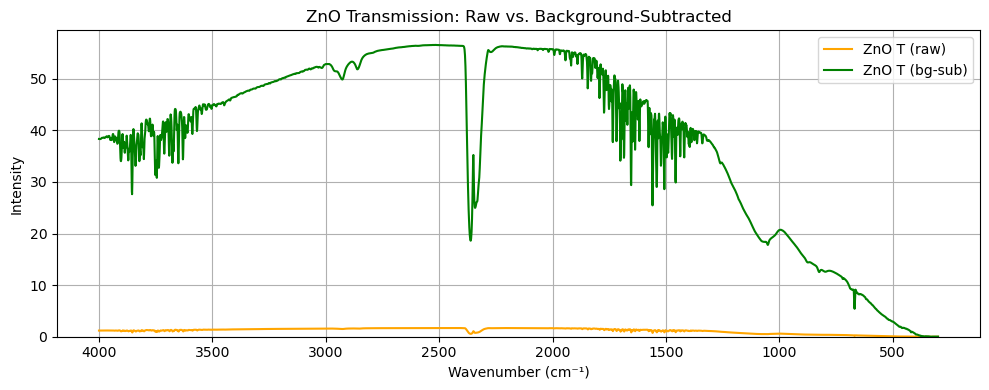

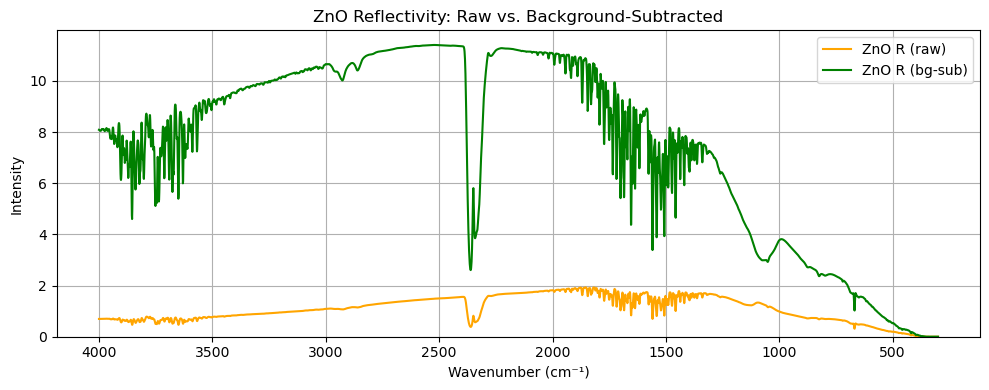

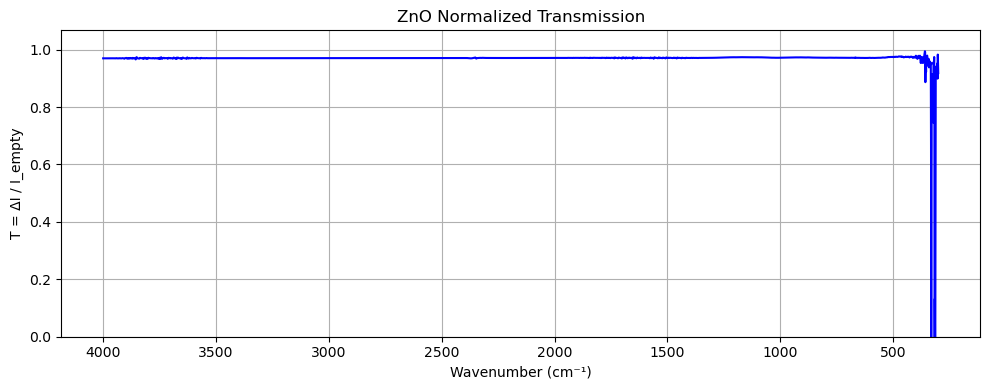

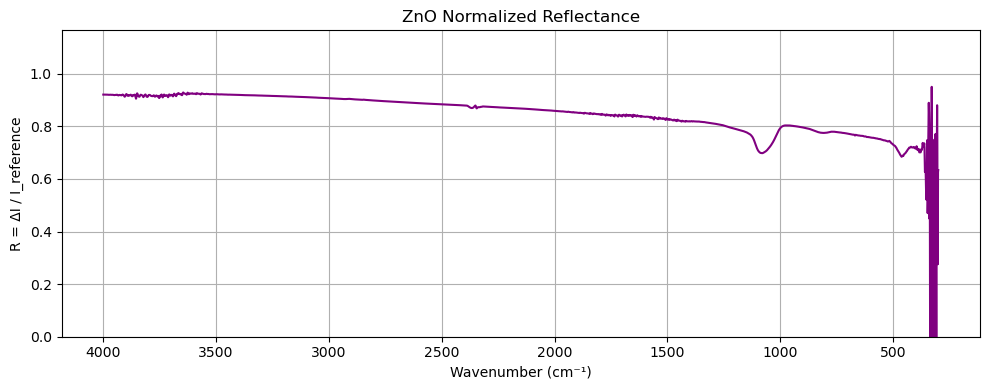

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Read .ASC files ---
def read_spectrum(filepath):
    with open(filepath, encoding='utf-8') as f:
        lines = f.readlines()[25:]
    data = []
    for line in lines:
        matches = re.findall(r"\d+,\d+", line)
        if len(matches) >= 2:
            wn = float(matches[0].replace(",", "."))
            intensity = float(matches[1].replace(",", "."))
            data.append((wn, intensity))
    return pd.DataFrame(data, columns=["Wavenumber", "Intensity"])

# --- Load ZnO data ---
df_trans    = read_spectrum("ZnO transmitted.ASC")
df_empty    = read_spectrum("znO incident empty.ASC")
df_refl     = read_spectrum("ZnO reflected.ASC")
df_refl_inc = read_spectrum("ZnO reflected incident..ASC")

# --- Interpolate backgrounds onto each grid ---
df_empty_i    = (
    df_empty.set_index("Wavenumber")
            .reindex(df_trans["Wavenumber"])
            .interpolate()
            .reset_index()
)
df_refl_inc_i = (
    df_refl_inc.set_index("Wavenumber")
               .reindex(df_refl["Wavenumber"])
               .interpolate()
               .reset_index()
)

# --- Flipped background subtraction (positive features) ---
df_trans["Subtracted"] = df_empty_i["Intensity"] - df_trans["Intensity"]
df_refl["Subtracted"]  = df_refl_inc_i["Intensity"] - df_refl["Intensity"]

# --- Normalized spectra (also ≥0) ---
df_trans["Transmittance"] = df_trans["Subtracted"] / df_empty_i["Intensity"]
df_refl["Reflectance"]    = df_refl["Subtracted"] / df_refl_inc_i["Intensity"]

# --- Plot 1: Transmission raw + bg-sub (all ≥0) ---
plt.figure(figsize=(10,4))
plt.plot(df_trans["Wavenumber"], df_trans["Intensity"],    label="ZnO T (raw)", color="orange")
plt.plot(df_trans["Wavenumber"], df_trans["Subtracted"],   label="ZnO T (bg-sub)", color="green")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("ZnO Transmission: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Reflection raw + bg-sub (all ≥0) ---
plt.figure(figsize=(10,4))
plt.plot(df_refl["Wavenumber"], df_refl["Intensity"],  label="ZnO R (raw)", color="orange")
plt.plot(df_refl["Wavenumber"], df_refl["Subtracted"], label="ZnO R (bg-sub)", color="green")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("ZnO Reflectivity: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 3: Normalized Transmittance (≥0) ---
plt.figure(figsize=(10,4))
plt.plot(df_trans["Wavenumber"], df_trans["Transmittance"], label="ZnO Transmittance", color="blue")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("ZnO Normalized Transmission")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("T = ΔI / I_empty")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 4: Normalized Reflectance (≥0) ---
plt.figure(figsize=(10,4))
plt.plot(df_refl["Wavenumber"], df_refl["Reflectance"], label="ZnO Reflectance", color="purple")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("ZnO Normalized Reflectance")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("R = ΔI / I_reference")
plt.grid(True)
plt.tight_layout()
plt.show()


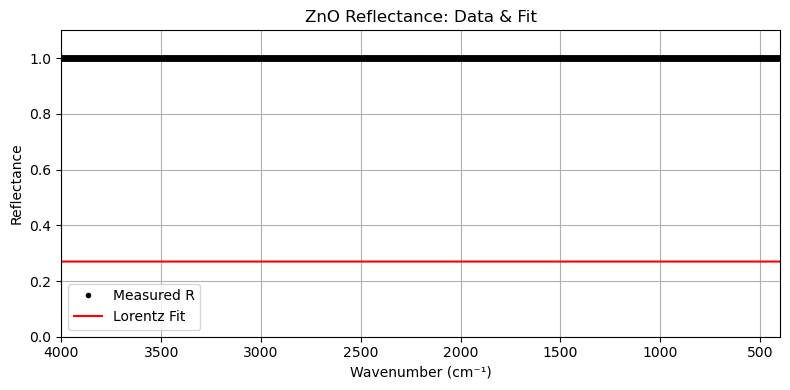

AttributeError: 'Series' object has no attribute 'real'

<Figure size 800x400 with 0 Axes>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit

# --- Read & normalize ZnO reflectance (reuse your previous read_asc) ---
def read_asc(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m)>=2:
            wn.append(float(m[0].replace(',', '.')))
            I.append(float(m[1].replace(',', '.')))
    return np.array(wn), np.array(I)

BASE = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration"

# load sample and reference‐incident
wn_r, I_r           = read_asc(f"{BASE}\\ZnO reflected.ASC")
wn_inc, I_inc       = read_asc(f"{BASE}\\ZnO reflected incident..ASC")
I_inc_i             = np.interp(wn_r, wn_inc, I_inc)

# background‐subtracted normalized reflectance
R_sub = (I_r - I_inc_i) / I_inc_i
R_sub = np.clip(R_sub, 0, 1)

# put in DataFrame for convenience
df_R = pd.DataFrame({
    "Wavenumber": wn_r,
    "Reflectance": R_sub
})

# --- 1) Fit R_sub to single‐oscillator Lorentz model ---
def eps_lorentz(nu, eps_inf, B, nu0, gamma):
    denom = (nu0**2 - nu**2) - 1j*gamma*nu
    return eps_inf + B**2 / denom

def R_model(nu, eps_inf, B, nu0, gamma):
    eps = eps_lorentz(nu, eps_inf, B, nu0, gamma)
    n   = np.sqrt(eps)
    r   = (n - 1)/(n + 1)
    return np.abs(r)**2

# initial guesses & bounds
p0     = [4.0, 200.0, 435.0, 20.0]
bounds = ([1.0,   0.0, 380.0,  1.0],
          [10.0,1000.0,500.0,100.0])

popt, _ = curve_fit(R_model, df_R["Wavenumber"], df_R["Reflectance"],
                    p0=p0, bounds=bounds, max_nfev=5000)
eps_inf_zno, B_zno, nu0_zno, gamma_zno = popt

# --- 2) Plot measured vs. fitted reflectance ---
plt.figure(figsize=(8,4))
plt.plot(df_R["Wavenumber"], df_R["Reflectance"], 'k.', label="Measured R")
plt.plot(df_R["Wavenumber"], R_model(df_R["Wavenumber"], *popt),
         'r-', label="Lorentz Fit")
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.ylim(0, 1.1)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectance")
plt.title("ZnO Reflectance: Data & Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 3) Compute & plot dielectric function from fitted parameters ---
eps_fit = eps_lorentz(df_R["Wavenumber"], *popt)

plt.figure(figsize=(8,4))
plt.plot(df_R["Wavenumber"], eps_fit.real, label=r'$\varepsilon_1$')
plt.plot(df_R["Wavenumber"], eps_fit.imag, label=r'$\varepsilon_2$')
plt.gca().invert_xaxis()
plt.xlim(4000, 400)
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Dielectric Function")
plt.title("ZnO Thin Film: Fitted Dielectric Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


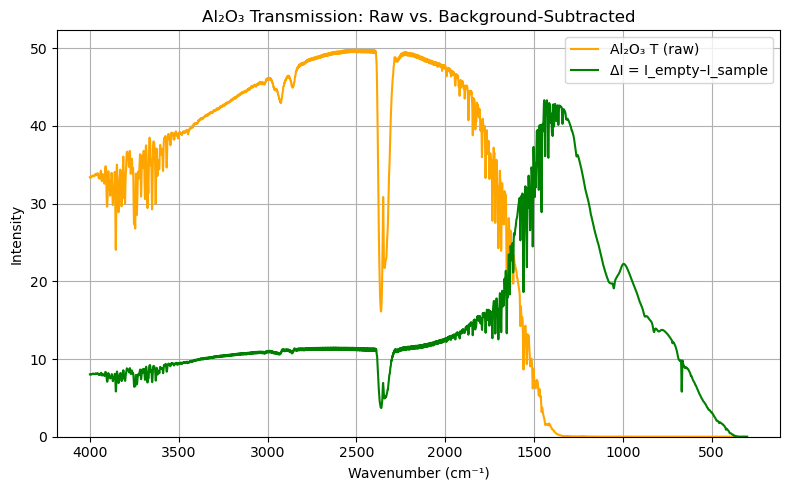

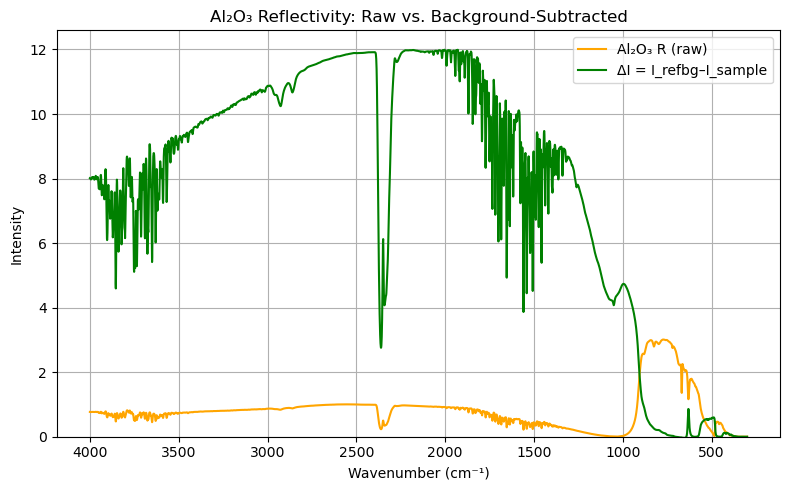

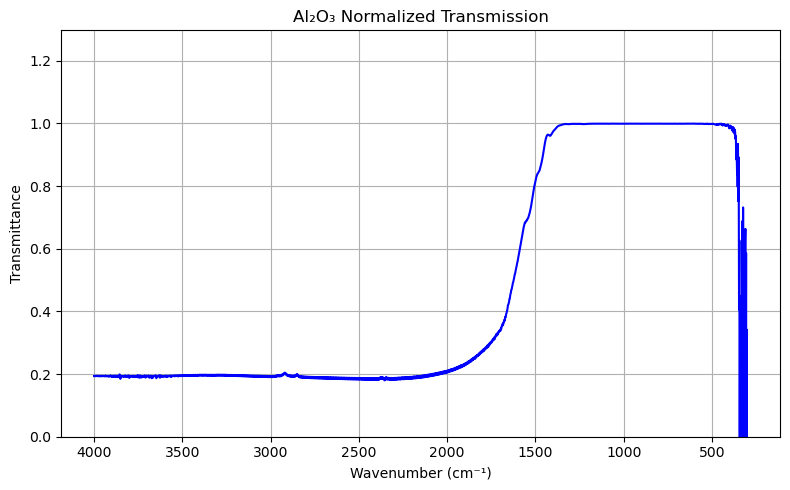

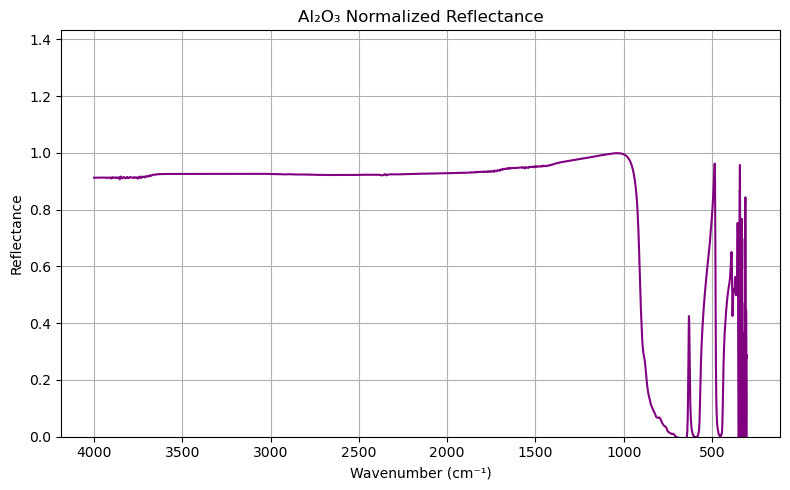

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

# --- Read .ASC files ---
def read_spectrum(filepath, skip=25):
    with open(filepath, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    data = []
    for line in lines:
        m = re.findall(r"\d+,\d+", line)
        if len(m) >= 2:
            wn = float(m[0].replace(",", "."))
            I  = float(m[1].replace(",", "."))
            data.append((wn, I))
    return pd.DataFrame(data, columns=["Wavenumber", "Intensity"])

# --- File paths ---
base = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration"
file_trans = f"{base}\\Al2O3.ASC"
file_empty = f"{base}\\Al2O3 empty.ASC"
file_ref   = f"{base}\\REF Al2O3 .ASC"
file_back  = f"{base}\\REF REFERENCE back.ASC"

# --- Load dataframes ---
df_T    = read_spectrum(file_trans)
df_empty= read_spectrum(file_empty)
df_R    = read_spectrum(file_ref)
df_back = read_spectrum(file_back)

# --- Interpolate backgrounds onto sample grids ---
df_empty_i = (
    df_empty.set_index("Wavenumber")
            .reindex(df_T["Wavenumber"])
            .interpolate()
            .reset_index()
)
df_back_i  = (
    df_back.set_index("Wavenumber")
           .reindex(df_R["Wavenumber"])
           .interpolate()
           .reset_index()
)

# --- Flipped background subtraction (positive features) ---
# Transmission: ΔI = I_empty – I_trans
df_T["Subtracted"] = df_empty_i["Intensity"] - df_T["Intensity"]
# Reflection: ΔI = I_back – I_ref
df_R["Subtracted"] = df_back_i["Intensity"] - df_R["Intensity"]

# --- Normalized spectra (≥0) ---
df_T["Transmittance"] = df_T["Subtracted"] / df_empty_i["Intensity"]
df_R["Reflectance"]    = df_R["Subtracted"] / df_back_i["Intensity"]

# --- Plot 1: Transmission raw & background‐subtracted ---
plt.figure(figsize=(8,5))
plt.plot(df_T["Wavenumber"], df_T["Intensity"],    label="Al₂O₃ T (raw)", color="orange")
plt.plot(df_T["Wavenumber"], df_T["Subtracted"],   label="ΔI = I_empty–I_sample", color="green")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("Al₂O₃ Transmission: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Reflection raw & background‐subtracted ---
plt.figure(figsize=(8,5))
plt.plot(df_R["Wavenumber"], df_R["Intensity"],    label="Al₂O₃ R (raw)", color="orange")
plt.plot(df_R["Wavenumber"], df_R["Subtracted"],   label="ΔI = I_refbg–I_sample", color="green")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("Al₂O₃ Reflectivity: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 3: Normalized Transmittance ---
plt.figure(figsize=(8,5))
plt.plot(df_T["Wavenumber"], df_T["Transmittance"], label="T = ΔI / I_empty", color="blue")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("Al₂O₃ Normalized Transmission")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Transmittance")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 4: Normalized Reflectance ---
plt.figure(figsize=(8,5))
plt.plot(df_R["Wavenumber"], df_R["Reflectance"], label="R = ΔI / I_ref", color="purple")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("Al₂O₃ Normalized Reflectance")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectance")
plt.grid(True)
plt.tight_layout()
plt.show()


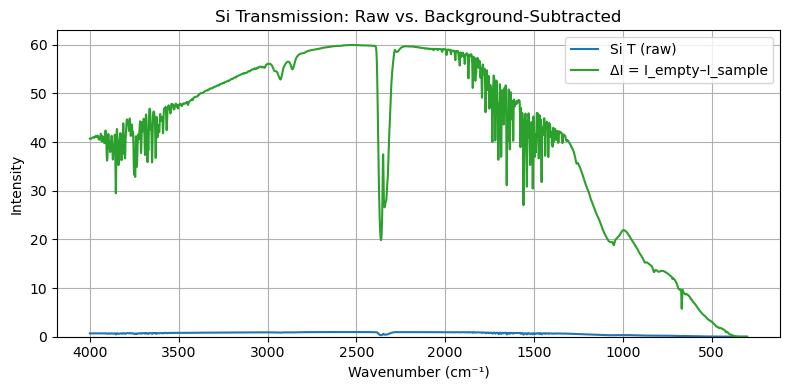

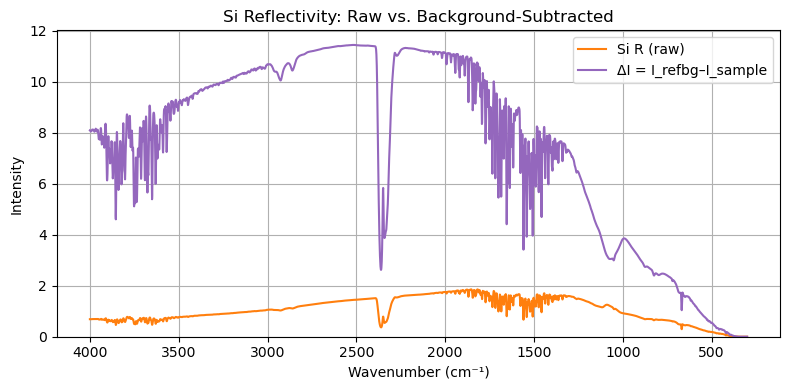

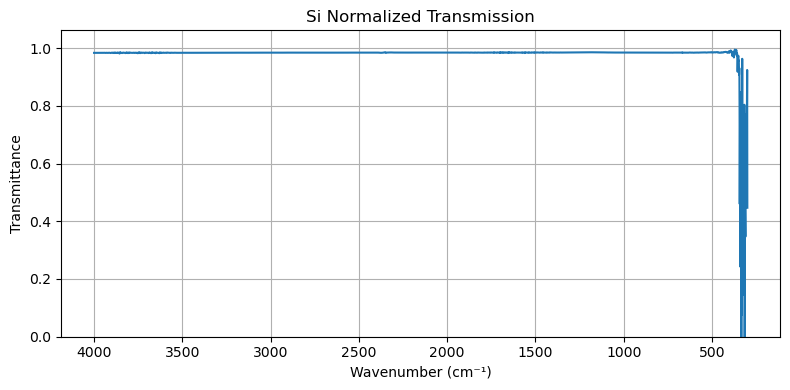

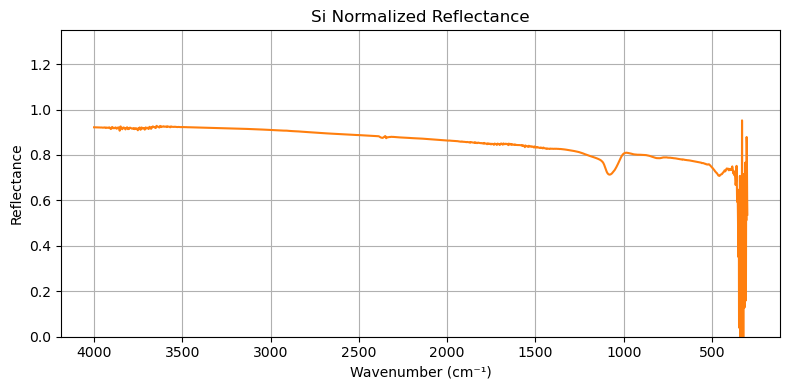

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

# --- Read .ASC files ---
def read_spectrum(filepath, skip=25):
    with open(filepath, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    data = []
    for line in lines:
        m = re.findall(r"\d+,\d+", line)
        if len(m) >= 2:
            wn = float(m[0].replace(",", "."))
            I  = float(m[1].replace(",", "."))
            data.append((wn, I))
    return pd.DataFrame(data, columns=["Wavenumber", "Intensity"])

# --- File paths ---
BASE         = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration"
file_trans   = f"{BASE}\\silicon trans.ASC"
file_empty   = f"{BASE}\\silicon empty.ASC"
file_refl    = f"{BASE}\\reflection Silicon.ASC"
file_refback = f"{BASE}\\REF REFERENCE back.ASC"

# --- Load dataframes ---
df_T    = read_spectrum(file_trans)
df_empty= read_spectrum(file_empty)
df_R    = read_spectrum(file_refl)
df_back = read_spectrum(file_refback)

# --- Interpolate backgrounds onto each grid ---
df_empty_i = (
    df_empty.set_index("Wavenumber")
            .reindex(df_T["Wavenumber"])
            .interpolate()
            .reset_index()
)
df_back_i  = (
    df_back.set_index("Wavenumber")
           .reindex(df_R["Wavenumber"])
           .interpolate()
           .reset_index()
)

# --- Flipped background subtraction (positive features) ---
# Transmission: ΔI = I_empty – I_trans
df_T["Subtracted"] = df_empty_i["Intensity"] - df_T["Intensity"]
# Reflection: ΔI = I_back – I_refl
df_R["Subtracted"] = df_back_i["Intensity"] - df_R["Intensity"]

# --- Normalized spectra (≥0) ---
df_T["Transmittance"] = df_T["Subtracted"] / df_empty_i["Intensity"]
df_R["Reflectance"]    = df_R["Subtracted"] / df_back_i["Intensity"]

# --- Plot 1: Transmission raw & background-subtracted ---
plt.figure(figsize=(8,4))
plt.plot(df_T["Wavenumber"], df_T["Intensity"],    label="Si T (raw)", color="tab:blue")
plt.plot(df_T["Wavenumber"], df_T["Subtracted"],   label="ΔI = I_empty–I_sample", color="tab:green")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("Si Transmission: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Reflection raw & background-subtracted ---
plt.figure(figsize=(8,4))
plt.plot(df_R["Wavenumber"], df_R["Intensity"],    label="Si R (raw)", color="tab:orange")
plt.plot(df_R["Wavenumber"], df_R["Subtracted"],   label="ΔI = I_refbg–I_sample", color="tab:purple")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("Si Reflectivity: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 3: Normalized Transmittance (≥0) ---
plt.figure(figsize=(8,4))
plt.plot(df_T["Wavenumber"], df_T["Transmittance"], label="T = ΔI / I_empty", color="tab:blue")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("Si Normalized Transmission")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Transmittance")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 4: Normalized Reflectance (≥0) ---
plt.figure(figsize=(8,4))
plt.plot(df_R["Wavenumber"], df_R["Reflectance"], label="R = ΔI / I_ref", color="tab:orange")
plt.gca().invert_xaxis()
plt.ylim(0)
plt.title("Si Normalized Reflectance")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectance")
plt.grid(True)
plt.tight_layout()
plt.show()


ε∞ = 5.00
B₁=1000.0, ν₁=450.0, b₁=1.0
B₂=1000.0, ν₂=472.6, b₂=1.0
B₃=1000.0, ν₃=550.7, b₃=1.0


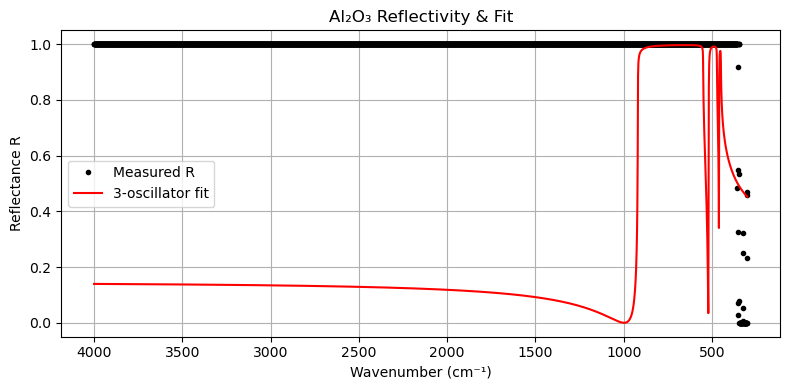

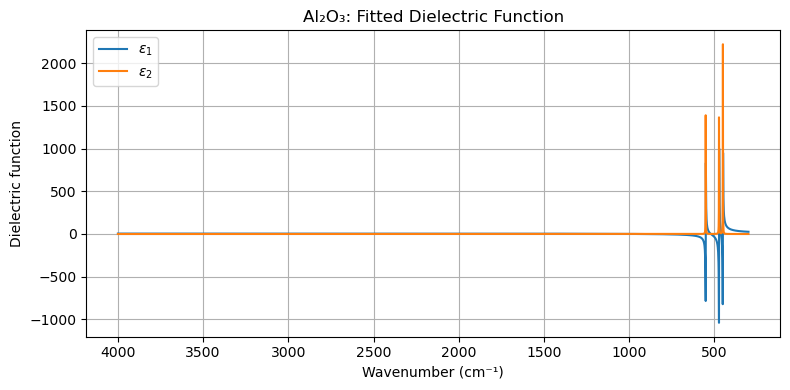

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit

# --- 1) Read & normalize reflectivity (background-subtracted) ---
def read_asc(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn,I = [],[]
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m)>=2:
            wn.append(float(m[0].replace(",", ".")))
            I.append(float(m[1].replace(",", ".")))
    return np.array(wn), np.array(I)

BASE    = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration"
REF     = read_asc(f"{BASE}\\REF Al2O3 .ASC")
BACK    = read_asc(f"{BASE}\\REF REFERENCE back.ASC")
wn_R,I_R=REF; wn_b,I_b=BACK
I_bi    = np.interp(wn_R, wn_b, I_b)
R       = np.clip((I_R - I_bi)/I_bi, 0, 1)   # background-subtracted normalized R

# --- 2) Define 3-oscillator dielectric & reflectance models ---
def eps_3osc(nu, eps_inf,
             B1, nu1, b1,
             B2, nu2, b2,
             B3, nu3, b3):
    eps = eps_inf
    for B, nu0, gam in ((B1,nu1,b1),(B2,nu2,b2),(B3,nu3,b3)):
        eps += B**2/((nu0**2 - nu**2) - 1j*gam*nu)
    return eps

def R_model(nu, *p):
    eps = eps_3osc(nu, *p)
    n   = np.sqrt(eps)
    r   = (1 - n)/(1 + n)
    return np.abs(r)**2

# --- 3) Initial guesses & bounds (tweak as needed) ---
# from literature: ε∞~3.2; TO phonons ~380, 440, 611 cm⁻¹; splittings few tens
p0 = [
    3.2,
    200, 380,  20,
    200, 440,  20,
    200, 611,  20
]
lower = [1.0,  0, 300,1,   0,400,1,   0,550,1]
upper = [5.0,1000,450,100,1000,500,100,1000,700,100]

popt, pcov = curve_fit(R_model, wn_R, R, p0=p0, bounds=(lower,upper), max_nfev=20000)
(eps_inf,
 B1,nu1,b1,
 B2,nu2,b2,
 B3,nu3,b3) = popt

# print extracted parameters
print(f"ε∞ = {eps_inf:.2f}")
print(f"B₁={B1:.1f}, ν₁={nu1:.1f}, b₁={b1:.1f}")
print(f"B₂={B2:.1f}, ν₂={nu2:.1f}, b₂={b2:.1f}")
print(f"B₃={B3:.1f}, ν₃={nu3:.1f}, b₃={b3:.1f}")

# --- 4) Plot the fit vs. data ---
plt.figure(figsize=(8,4))
plt.plot(wn_R, R,   'k.', label="Measured R")
plt.plot(wn_R, R_model(wn_R,*popt), 'r-', label="3-oscillator fit")
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectance R")
plt.title("Al₂O₃ Reflectivity & Fit")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# --- 5) Compute & plot ε₁, ε₂ over full range ---
eps_fit = eps_3osc(wn_R, *popt)
plt.figure(figsize=(8,4))
plt.plot(wn_R, eps_fit.real, label=r'$\varepsilon_1$')
plt.plot(wn_R, eps_fit.imag, label=r'$\varepsilon_2$')
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Dielectric function")
plt.title("Al₂O₃: Fitted Dielectric Function")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


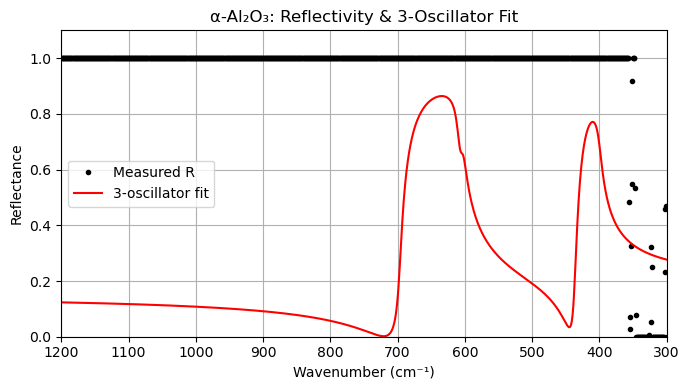

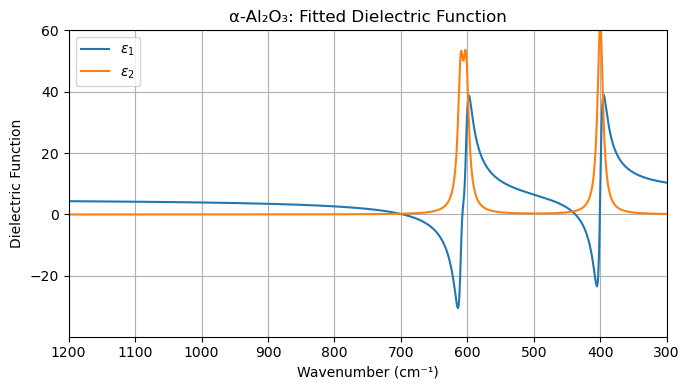

Fitted α-Al₂O₃ Dielectric Model Parameters:
 ε∞   = 5.00
 B₁   = 500.0, ν₁  = 400.0 cm⁻¹, b₁  = 10.0 cm⁻¹
 B₂   = 500.0, ν₂  = 602.0 cm⁻¹, b₂  = 10.0 cm⁻¹
 B₃   = 500.0, ν₃  = 610.0 cm⁻¹, b₃  = 10.0 cm⁻¹

Fitted α-Al₂O₃ Dielectric Model Parameters:

Parameter                        Description   Value
       ε∞ High‐frequency dielectric constant   5.000
       B₁        Oscillator strength, mode 1 500.000
       ν₁     TO phonon freq., mode 1 (cm⁻¹) 400.000
       b₁             Damping, mode 1 (cm⁻¹)  10.000
       B₂        Oscillator strength, mode 2 500.000
       ν₂     TO phonon freq., mode 2 (cm⁻¹) 601.954
       b₂             Damping, mode 2 (cm⁻¹)  10.000
       B₃        Oscillator strength, mode 3 500.000
       ν₃     TO phonon freq., mode 3 (cm⁻¹) 610.000
       b₃             Damping, mode 3 (cm⁻¹)  10.000


In [11]:
##### import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit

# 1) Read & background‐subtract reflectivity
def read_spectrum(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn.append(float(m[0].replace(',', '.')))
            I.append(float(m[1].replace(',', '.')))
    return np.array(wn), np.array(I)

REF_FILE = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\REF Al2O3 .ASC"
BACK_FILE= r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration\REF REFERENCE back.ASC"

wn_s, I_s = read_spectrum(REF_FILE)
wn_b, I_b = read_spectrum(BACK_FILE)

R_raw    = I_s
R_sub    = I_s - np.interp(wn_s, wn_b, I_b)
R_norm   = np.clip(R_sub / np.interp(wn_s, wn_b, I_b), 0, 1)

# restrict to fitting window
mask  = (wn_s >= 300) & (wn_s <= 1200)
nu    = wn_s[mask]
R_fit = R_norm[mask]

# 2) Three-oscillator Lorentz model (Bj notation)
def eps_3osc_B(nu, eps_inf,
               B1, nu1, b1,
               B2, nu2, b2,
               B3, nu3, b3):
    eps = eps_inf
    for B, nu0, gam in ((B1, nu1, b1),
                        (B2, nu2, b2),
                        (B3, nu3, b3)):
        denom = (nu0**2 - nu**2) - 1j*(gam*nu)
        eps += B**2 / denom
    return eps

def R_model(nu, *p):
    eps = eps_3osc_B(nu, *p)
    n   = np.sqrt(eps)
    r   = (1 - n)/(1 + n)
    return np.abs(r)**2

# 3) Initial guesses & bounds (TO at 377, 574, 647 cm⁻¹)
p0 = [
    3.2,
    100, 377,  30,
    200, 574,  40,
    150, 647,  50
]
lower = [2.0,   0, 350, 10,   0, 540, 10,   0, 610, 10]
upper = [5.0, 500, 400, 80, 500, 610, 80, 500, 700, 80]

popt, pcov = curve_fit(R_model, nu, R_fit,
                       p0=p0, bounds=(lower, upper),
                       max_nfev=20000)
(eps_inf, 
 B1,nu1,b1,
 B2,nu2,b2,
 B3,nu3,b3) = popt

# 4) Compute eps_fit over the fitting window
eps_fit = eps_3osc_B(nu, *popt)

# 5) Determine y‐limits with 10% margin
ymin = min(eps_fit.real.min(), eps_fit.imag.min())
ymax = max(eps_fit.real.max(), eps_fit.imag.max())
dy   = ymax - ymin
y_lo = max(ymin - 0.1*dy, -60)
y_hi = min(ymax + 0.1*dy,  60)

# 6) Plot measured vs. fit reflectivity
plt.figure(figsize=(7,4))
plt.plot(nu, R_fit,  'k.', label="Measured R")
plt.plot(nu, R_model(nu, *popt), 'r-', label="3-oscillator fit")
plt.gca().invert_xaxis()
plt.xlim(1200, 300)
plt.ylim(0, 1.1)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectance")
plt.title("α-Al₂O₃: Reflectivity & 3-Oscillator Fit")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# 7) Plot fitted ε₁ & ε₂
plt.figure(figsize=(7,4))
plt.plot(nu, eps_fit.real, label=r'$\varepsilon_1$')
plt.plot(nu, eps_fit.imag, label=r'$\varepsilon_2$')
plt.gca().invert_xaxis()
plt.xlim(1200, 300)
plt.ylim(y_lo, y_hi)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Dielectric Function")
plt.title("α-Al₂O₃: Fitted Dielectric Function")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# 8) Print out nicely labeled parameters
print("Fitted α-Al₂O₃ Dielectric Model Parameters:")
print(f" ε∞   = {eps_inf:.2f}")
print(f" B₁   = {B1:.1f}, ν₁  = {nu1:.1f} cm⁻¹, b₁  = {b1:.1f} cm⁻¹")
print(f" B₂   = {B2:.1f}, ν₂  = {nu2:.1f} cm⁻¹, b₂  = {b2:.1f} cm⁻¹")
print(f" B₃   = {B3:.1f}, ν₃  = {nu3:.1f} cm⁻¹, b₃  = {b3:.1f} cm⁻¹")

import pandas as pd

# --- After popt has been determined ---
param_list = [
    ("ε∞",   "High‐frequency dielectric constant",           eps_inf),
    ("B₁",   "Oscillator strength, mode 1",                  B1),
    ("ν₁",   "TO phonon freq., mode 1 (cm⁻¹)",                nu1),
    ("b₁",   "Damping, mode 1 (cm⁻¹)",                        b1),
    ("B₂",   "Oscillator strength, mode 2",                  B2),
    ("ν₂",   "TO phonon freq., mode 2 (cm⁻¹)",                nu2),
    ("b₂",   "Damping, mode 2 (cm⁻¹)",                        b2),
    ("B₃",   "Oscillator strength, mode 3",                  B3),
    ("ν₃",   "TO phonon freq., mode 3 (cm⁻¹)",                nu3),
    ("b₃",   "Damping, mode 3 (cm⁻¹)",                        b3),
]

df_params = pd.DataFrame(param_list, columns=["Parameter", "Description", "Value"])
df_params["Value"] = df_params["Value"].map(lambda x: f"{x:.3f}")

print("\nFitted α-Al₂O₃ Dielectric Model Parameters:\n")
print(df_params.to_string(index=False))


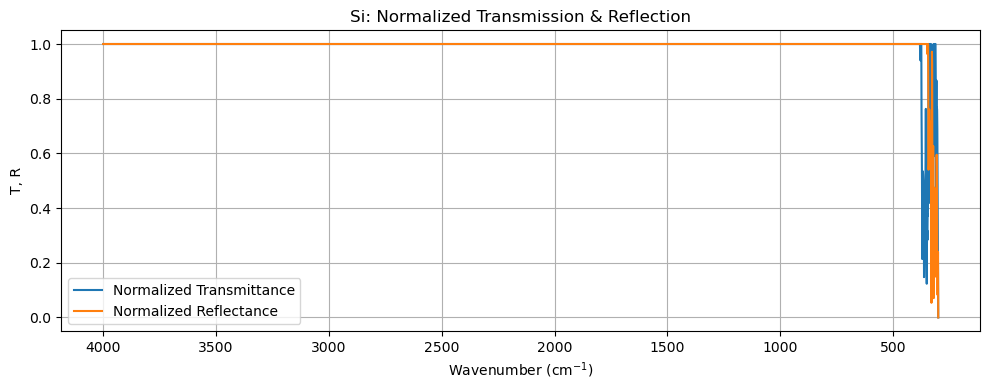

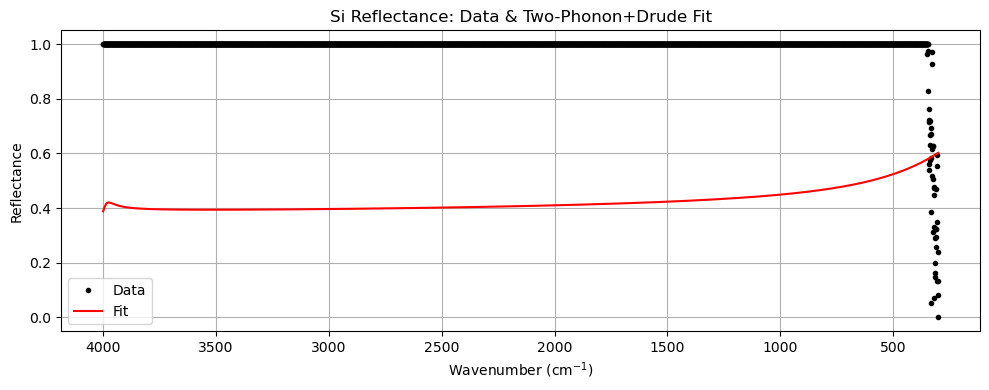

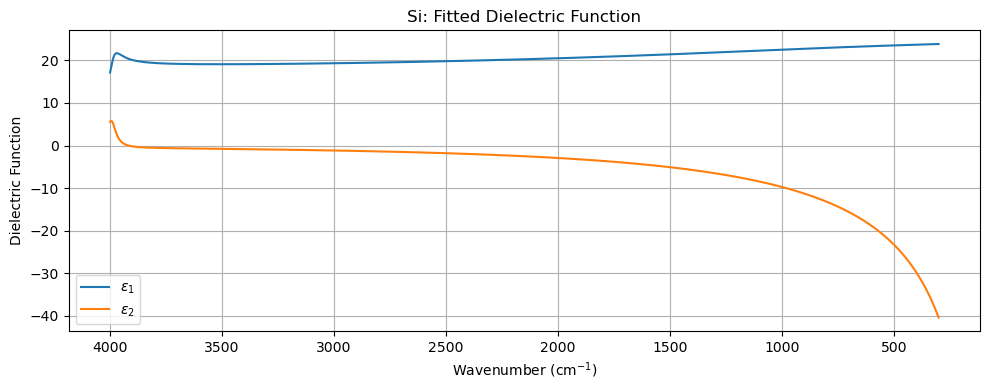

ε∞   = 17.266
B₁   = 1115.400
ν₁   = 3994.700
b₁   = 48.950
B₂   = 1000.000
ν₂   = 131.900
b₂   = 1239.750
ν_p  = 4935.300
b_e  = 1841.600


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit

# 1) Reader for Bruker .ASC files
def read_asc(path, skip=25):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    wn, I = [], []
    for L in lines:
        m = re.findall(r"\d+,\d+", L)
        if len(m) >= 2:
            wn.append(float(m[0].replace(',', '.')))
            I.append(float(m[1].replace(',', '.')))
    return np.array(wn), np.array(I)

# 2) File locations (your folder)
BASE = r"C:\Users\Lenovo\Documents\Study\8th Semester\Advance labs\lattice vibration"
# Transmission
wn_T, I_T    = read_asc(f"{BASE}\\silicon trans.ASC")
wn_empty, I_empty = read_asc(f"{BASE}\\silicon empty.ASC")
# Reflection
wn_R, I_R    = read_asc(f"{BASE}\\reflection Silicon.ASC")
wn_ref, I_ref = read_asc(f"{BASE}\\REF REFERENCE back.ASC")

# 3) Normalize
I_empty_i = np.interp(wn_T, wn_empty, I_empty)
T = np.clip(I_T / I_empty_i, 0, 1)

I_ref_i = np.interp(wn_R, wn_ref, I_ref)
R = np.clip(I_R / I_ref_i, 0, 1)

# 4) Plot normalized transmission & reflection
plt.figure(figsize=(10,4))
plt.plot(wn_T, T, label="Normalized Transmittance", color="tab:blue")
plt.plot(wn_R, R, label="Normalized Reflectance",  color="tab:orange")
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("T, R")
plt.title("Si: Normalized Transmission & Reflection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5) Two-phonon + Drude dielectric model (Task 4) :contentReference[oaicite:1]{index=1}
def eps_si(nu, eps_inf,
           B1, nu1, b1,
           B2, nu2, b2,
           nu_p, b_e):
    eps = eps_inf
    eps += B1**2 / (nu1**2 - nu**2 - 1j*b1*nu)
    eps += B2**2 / (nu2**2 - nu**2 - 1j*b2*nu)
    eps += nu_p**2 / (nu**2 + 1j*b_e*nu)
    return eps

def R_model(nu, *p):
    eps = eps_si(nu, *p)
    n    = np.sqrt(eps)
    r    = (1 - n)/(1 + n)
    return np.abs(r)**2

# 6) Initial guesses & bounds from Table 4 :contentReference[oaicite:2]{index=2}
p0 = [
    11.511,    # ε∞
    743.6, 4011.9, 97.9,   # B1, ν1, b1
    2000.0, 263.8, 826.5,  # B2, ν2, b2
    3290.2, 3683.2         # ν_p, b_e
]
# Allow ±20% variation
lower = [x*0.5 for x in p0]
upper = [x*1.5 for x in p0]

popt, pcov = curve_fit(
    R_model,
    wn_R, R,
    p0=p0,
    bounds=(lower, upper),
    max_nfev=20000
)

# 7) Overlay fit
R_fit = R_model(wn_R, *popt)
plt.figure(figsize=(10,4))
plt.plot(wn_R, R,    'k.', label="Data")
plt.plot(wn_R, R_fit, 'r-', label="Fit")
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Reflectance")
plt.title("Si Reflectance: Data & Two-Phonon+Drude Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 8) Plot ε₁ and ε₂
eps_fit = eps_si(wn_R, *popt)
plt.figure(figsize=(10,4))
plt.plot(wn_R, eps_fit.real, label=r'$\varepsilon_1$')
plt.plot(wn_R, eps_fit.imag, label=r'$\varepsilon_2$')
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Dielectric Function")
plt.title("Si: Fitted Dielectric Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 9) Print fitted parameters
names = ["ε∞","B₁","ν₁","b₁","B₂","ν₂","b₂","ν_p","b_e"]
for n,val in zip(names, popt):
    print(f"{n:<4} = {val:.3f}")


In [13]:
import pandas as pd

# 10) Build a table of fitted parameters with descriptions
param_info = [
    ("ε∞",  "High‐frequency dielectric constant",                popt[0]),
    ("B₁",  "Oscillator strength, phonon 1",                     popt[1]),
    ("ν₁",  "TO phonon 1 frequency (cm⁻¹)",                       popt[2]),
    ("b₁",  "Damping, phonon 1 (cm⁻¹)",                          popt[3]),
    ("B₂",  "Oscillator strength, phonon 2",                     popt[4]),
    ("ν₂",  "TO phonon 2 frequency (cm⁻¹)",                       popt[5]),
    ("b₂",  "Damping, phonon 2 (cm⁻¹)",                          popt[6]),
    ("νₚ",  "Plasma frequency (cm⁻¹)",                           popt[7]),
    ("bₑ",  "Electronic damping (Drude) (cm⁻¹)",                 popt[8]),
]

df_params = pd.DataFrame(param_info, columns=["Parameter", "Description", "Value"])
df_params["Value"] = df_params["Value"].map(lambda x: f"{x:.3f}")

print("\nFitted Si Dielectric Model Parameters:\n")
print(df_params.to_string(index=False))



Fitted Si Dielectric Model Parameters:

Parameter                        Description    Value
       ε∞ High‐frequency dielectric constant   17.266
       B₁      Oscillator strength, phonon 1 1115.400
       ν₁       TO phonon 1 frequency (cm⁻¹) 3994.700
       b₁           Damping, phonon 1 (cm⁻¹)   48.950
       B₂      Oscillator strength, phonon 2 1000.000
       ν₂       TO phonon 2 frequency (cm⁻¹)  131.900
       b₂           Damping, phonon 2 (cm⁻¹) 1239.750
       νₚ            Plasma frequency (cm⁻¹) 4935.300
       bₑ  Electronic damping (Drude) (cm⁻¹) 1841.600


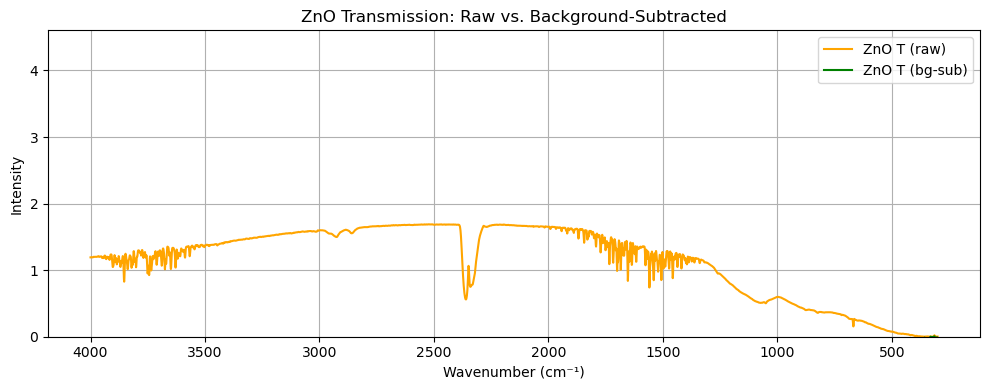

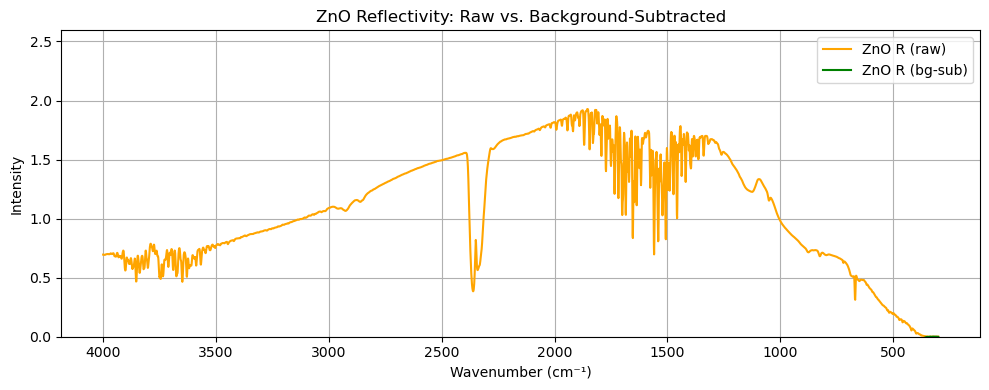

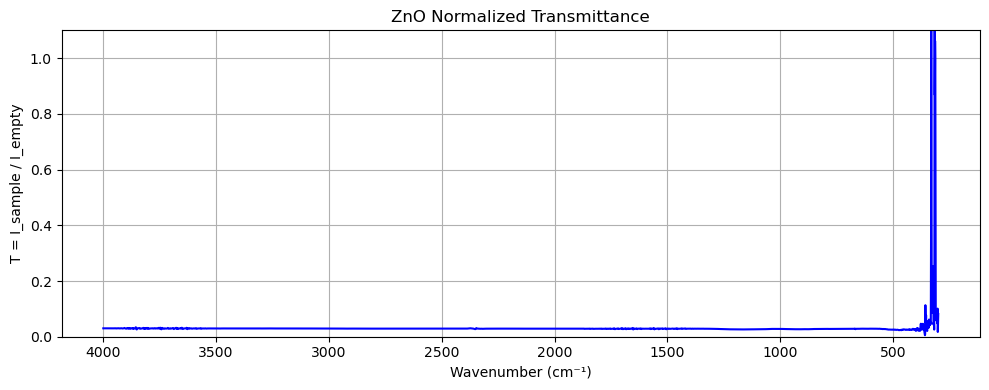

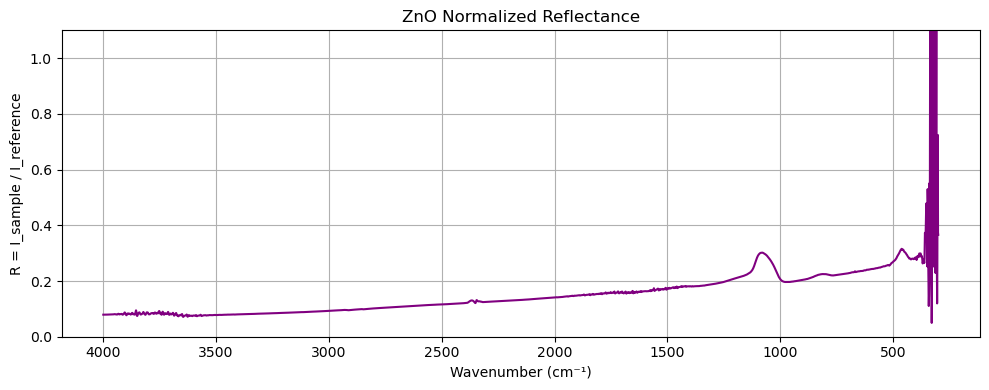

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Read .ASC files ---
def read_spectrum(filepath, skip=25):
    with open(filepath, encoding='utf-8') as f:
        lines = f.readlines()[skip:]
    data = []
    for line in lines:
        m = re.findall(r"\d+,\d+", line)
        if len(m) >= 2:
            wn = float(m[0].replace(",", "."))
            I  = float(m[1].replace(",", "."))
            data.append((wn, I))
    return pd.DataFrame(data, columns=["Wavenumber", "Intensity"])

# --- Load ZnO data ---
df_trans    = read_spectrum("ZnO transmitted.ASC")
df_empty    = read_spectrum("znO incident empty.ASC")
df_refl     = read_spectrum("ZnO reflected.ASC")
df_refl_inc = read_spectrum("ZnO reflected incident..ASC")

# --- Interpolate incident/reference onto each sample grid ---
df_empty_i    = (
    df_empty.set_index("Wavenumber")
            .reindex(df_trans["Wavenumber"])
            .interpolate()
            .reset_index()
)
df_refl_inc_i = (
    df_refl_inc.set_index("Wavenumber")
               .reindex(df_refl["Wavenumber"])
               .interpolate()
               .reset_index()
)

# --- Background subtraction for raw‐data plots only (optional) ---
df_trans["Subtracted"] = df_trans["Intensity"] - df_empty_i["Intensity"]
df_refl["Subtracted"]  = df_refl["Intensity"]  - df_refl_inc_i["Intensity"]

# --- Normalized spectra by direct division ---
df_trans["Transmittance"] = df_trans["Intensity"] / df_empty_i["Intensity"]
df_refl["Reflectance"]    = df_refl["Intensity"] / df_refl_inc_i["Intensity"]

# --- Plot 1: Transmission raw + background‐subtracted ---
plt.figure(figsize=(10,4))
plt.plot(df_trans["Wavenumber"], df_trans["Intensity"],   label="ZnO T (raw)", color="orange")
plt.plot(df_trans["Wavenumber"], df_trans["Subtracted"],  label="ZnO T (bg-sub)", color="green")
plt.gca().invert_xaxis()
plt.ylim(bottom=0)
plt.title("ZnO Transmission: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Reflection raw + background‐subtracted ---
plt.figure(figsize=(10,4))
plt.plot(df_refl["Wavenumber"], df_refl["Intensity"],    label="ZnO R (raw)", color="orange")
plt.plot(df_refl["Wavenumber"], df_refl["Subtracted"],    label="ZnO R (bg-sub)", color="green")
plt.gca().invert_xaxis()
plt.ylim(bottom=0)
plt.title("ZnO Reflectivity: Raw vs. Background-Subtracted")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 3: Normalized Transmittance ---
plt.figure(figsize=(10,4))
plt.plot(df_trans["Wavenumber"], df_trans["Transmittance"], label="ZnO Transmittance", color="blue")
plt.gca().invert_xaxis()
plt.ylim(0,1.1)
plt.title("ZnO Normalized Transmittance")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("T = I_sample / I_empty")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 4: Normalized Reflectance ---
plt.figure(figsize=(10,4))
plt.plot(df_refl["Wavenumber"], df_refl["Reflectance"], label="ZnO Reflectance", color="purple")
plt.gca().invert_xaxis()
plt.ylim(0,1.1)
plt.title("ZnO Normalized Reflectance")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("R = I_sample / I_reference")
plt.grid(True)
plt.tight_layout()
plt.show()


Fitted ZnO parameters:
 ε∞=10.00, B=1102.6, ν0=350.0 cm⁻¹, γ=200.0 cm⁻¹


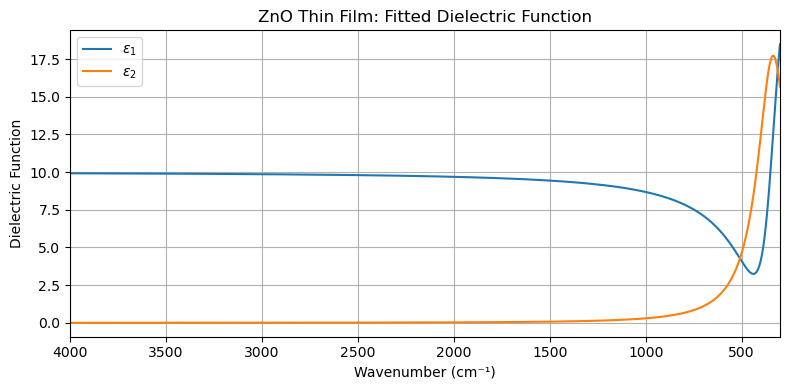

In [3]:
import numpy as np
from scipy.optimize import curve_fit

# --- 1) Prepare data for fitting ---
nu  = df_refl["Wavenumber"].values
R   = df_refl["Reflectance"].values

# restrict to the phonon region if you like (optional):
mask = (nu >= 300) & (nu <= 1000)
nu_fit = nu[mask]
R_fit  = R[mask]

# --- 2) Define single–oscillator Lorentz dielectric fn & reflectance model ---
def eps_lorentz(nu, eps_inf, B, nu0, gamma):
    """
    ε(ν) = ε_inf + B^2 / (ν0^2 - ν^2 - i γ ν)
    """
    denom = (nu0**2 - nu**2) - 1j*gamma*nu
    return eps_inf + B**2/denom

def R_model(nu, eps_inf, B, nu0, gamma):
    eps = eps_lorentz(nu, eps_inf, B, nu0, gamma)
    n   = np.sqrt(eps)
    r   = (n - 1)/(n + 1)
    return np.abs(r)**2

# --- 3) Fit to the measured R ---
p0 = [4.0, 200.0, 435.0, 20.0]          # guess: ε∞, B, ν0≈435cm⁻¹, γ
bounds = ([1,0,350,1], [10,1e4,600,200])

popt, _ = curve_fit(R_model, nu_fit, R_fit, p0=p0, bounds=bounds, max_nfev=5000)
eps_inf_zno, B_zno, nu0_zno, gamma_zno = popt

print(f"Fitted ZnO parameters:\n ε∞={eps_inf_zno:.2f}, B={B_zno:.1f}, ν0={nu0_zno:.1f} cm⁻¹, γ={gamma_zno:.1f} cm⁻¹")

# --- 4) Compute dielectric function over full range ---
eps_full = eps_lorentz(nu, *popt)

# --- 5) Plot ε₁ and ε₂ ---
plt.figure(figsize=(8,4))
plt.plot(nu, eps_full.real, label=r'$\varepsilon_1$')
plt.plot(nu, eps_full.imag, label=r'$\varepsilon_2$')
plt.gca().invert_xaxis()
plt.xlim(4000, 300)                    # reverse axis from 1000→300
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Dielectric Function")
plt.title("ZnO Thin Film: Fitted Dielectric Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
